In [1]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from deepview.calculate_results.models.utils import (
labeldict_findstr,
majority_value,
    labeldict_findstr,
)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score


def load_data(file_name):
    with open(os.path.join(root_path, file_name), 'rb') as f:
        data = pickle.load(f)
    return data

# 不同combination of sensors的f1 score

In [8]:
# fig2的几个active learning比较

root_path = r'D:\code\DeepView\deepview\calculate_results\data\umineko'
# active learning采用random sampling方法
base_acc = []
base_pred_label_lists, base_true_label_lists, base_selected_labels_list = [], [], []
base_ari_list, base_nmi_list, base_fmi_list = [], [], []
base_silhouette_list, base_label_data_list, base_unlabel_data_list = [], [], []
for sid in [30,31,32,33,34]:
    # file_name = 'AccelPress__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    file_name = 'acc_prs__entropy_Contrast1_warm20_seed%d_new_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    base_acc.append(result_dict['test_micro_f1_list'])
    base_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    base_true_label_lists.append(result_dict2['test_truth_label_lists'])


entropy_acc = []
entropy_pred_label_lists, entropy_true_label_lists, entropy_selected_labels_list = [], [], []
entropy_ari_list, entropy_nmi_list, entropy_fmi_list = [], [], []
entropy_silhouette_list, entropy_label_data_list, entropy_unlabel_data_list = [], [], []
for sid in [30,31,32,33,34]:
    # file_name = 'AccelGyro__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    file_name = 'acc_gyr__entropy_Contrast1_warm20_seed%d_new_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    entropy_acc.append(result_dict['test_micro_f1_list'])
    entropy_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    entropy_true_label_lists.append(result_dict2['test_truth_label_lists'])


underRandom_acc = []
underRandom_pred_label_lists, underRandom_true_label_lists, underRandom_selected_labels_list = [], [], []
underRandom_ari_list, underRandom_nmi_list, underRandom_fmi_list = [], [], []
underRandom_silhouette_list, underRandom_label_data_list, underRandom_unlabel_data_list = [], [], []
for sid in [30,31,32,33,34]:
    # file_name = 'PressTemp__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    file_name = 'prs_tmp__entropy_Contrast1_warm20_seed%d_new_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    underRandom_acc.append(result_dict['test_micro_f1_list'])
    underRandom_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    underRandom_true_label_lists.append(result_dict2['test_truth_label_lists'])
    

overAugment_acc = []
overAugment_pred_label_lists, overAugment_true_label_lists, overAugment_selected_labels_list = [], [], []
overAugment_ari_list, overAugment_nmi_list, overAugment_fmi_list = [], [], []
overAugment_silhouette_list, overAugment_label_data_list, overAugment_unlabel_data_list = [], [], []
for sid in [30,31,32,33,34]:
    # file_name = 'AccelGPS__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    file_name = 'acc_gpsbv__entropy_Contrast1_warm20_seed%d_new_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    overAugment_acc.append(result_dict['test_micro_f1_list'])
    overAugment_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    overAugment_true_label_lists.append(result_dict2['test_truth_label_lists'])
    

# representative sampling
repreSamp_acc = []
repreSamp_pred_label_lists, repreSamp_true_label_lists, repreSamp_selected_labels_list = [], [], []
repreSamp_ari_list, repreSamp_nmi_list, repreSamp_fmi_list = [], [], []
repreSamp_silhouette_list, repreSamp_label_data_list, repreSamp_unlabel_data_list = [], [], []
for sid in [30,31,32,33,34]:
    file_name = 'Accel__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    repreSamp_acc.append(result_dict['test_micro_f1_list'])
    repreSamp_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    repreSamp_true_label_lists.append(result_dict2['test_truth_label_lists'])
    

entropy1_acc = []
entropy1_pred_label_lists, entropy1_true_label_lists, entropy1_selected_labels_list = [], [], []
for sid in [30,31,32,33,34]:
    # file_name = 'AccelTemp__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    file_name = 'acc_tmp__entropy_Contrast1_warm20_seed%d_new_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    entropy1_acc.append(result_dict['test_micro_f1_list'])
    entropy1_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    entropy1_true_label_lists.append(result_dict2['test_truth_label_lists'])
    
    

all_acc = []
all_pred_label_lists, all_true_label_lists, all_selected_labels_list = [], [], []
for sid in [30,31,32,33,34]:
    file_name = 'acc_gyr_mag_prs_tmp_gpsbv_illum__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    all_acc.append(result_dict['test_micro_f1_list'])
    all_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    all_true_label_lists.append(result_dict2['test_truth_label_lists'])
    
    
accmag_acc = []
accmag_pred_label_lists, accmag_true_label_lists, accmag_selected_labels_list = [], [], []
for sid in [30,31,32,33,34]:
    file_name = 'acc_mag__entropy_Contrast1_warm20_seed%d_new_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    accmag_acc.append(result_dict['test_micro_f1_list'])
    accmag_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    accmag_true_label_lists.append(result_dict2['test_truth_label_lists'])
    
    
    
    
accillu_acc = []
accillu_pred_label_lists, accillu_true_label_lists, accillu_selected_labels_list = [], [], []
for sid in [30,31,32,33,34]:
    file_name = 'acc_illum__entropy_Contrast1_warm20_seed%d_new_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    accillu_acc.append(result_dict['test_micro_f1_list'])
    accillu_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    accillu_true_label_lists.append(result_dict2['test_truth_label_lists'])
    
# 
# entropy2_acc = []
# entropy2_pred_label_lists, entropy2_true_label_lists, entropy2_selected_labels_list = [], [], []
# # for sid in [30,31,32,33,34]:
# for sid in [1,2,5,10,2025]:
#     file_name = 'AccelTemp__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
#     with open(os.path.join(root_path, file_name), 'rb') as f:
#         pickle.load(f)
#         pickle.load(f)
#         pickle.load(f)
#         pickle.load(f)
#         pickle.load(f)
#         result_dict = pickle.load(f)
#         result_dict1 = pickle.load(f)
#         result_dict2 = pickle.load(f)
#     entropy2_acc.append(result_dict['test_micro_f1_list'])
#     entropy2_pred_label_lists.append(result_dict1['test_pred_label_lists'])
#     entropy2_true_label_lists.append(result_dict2['test_truth_label_lists'])


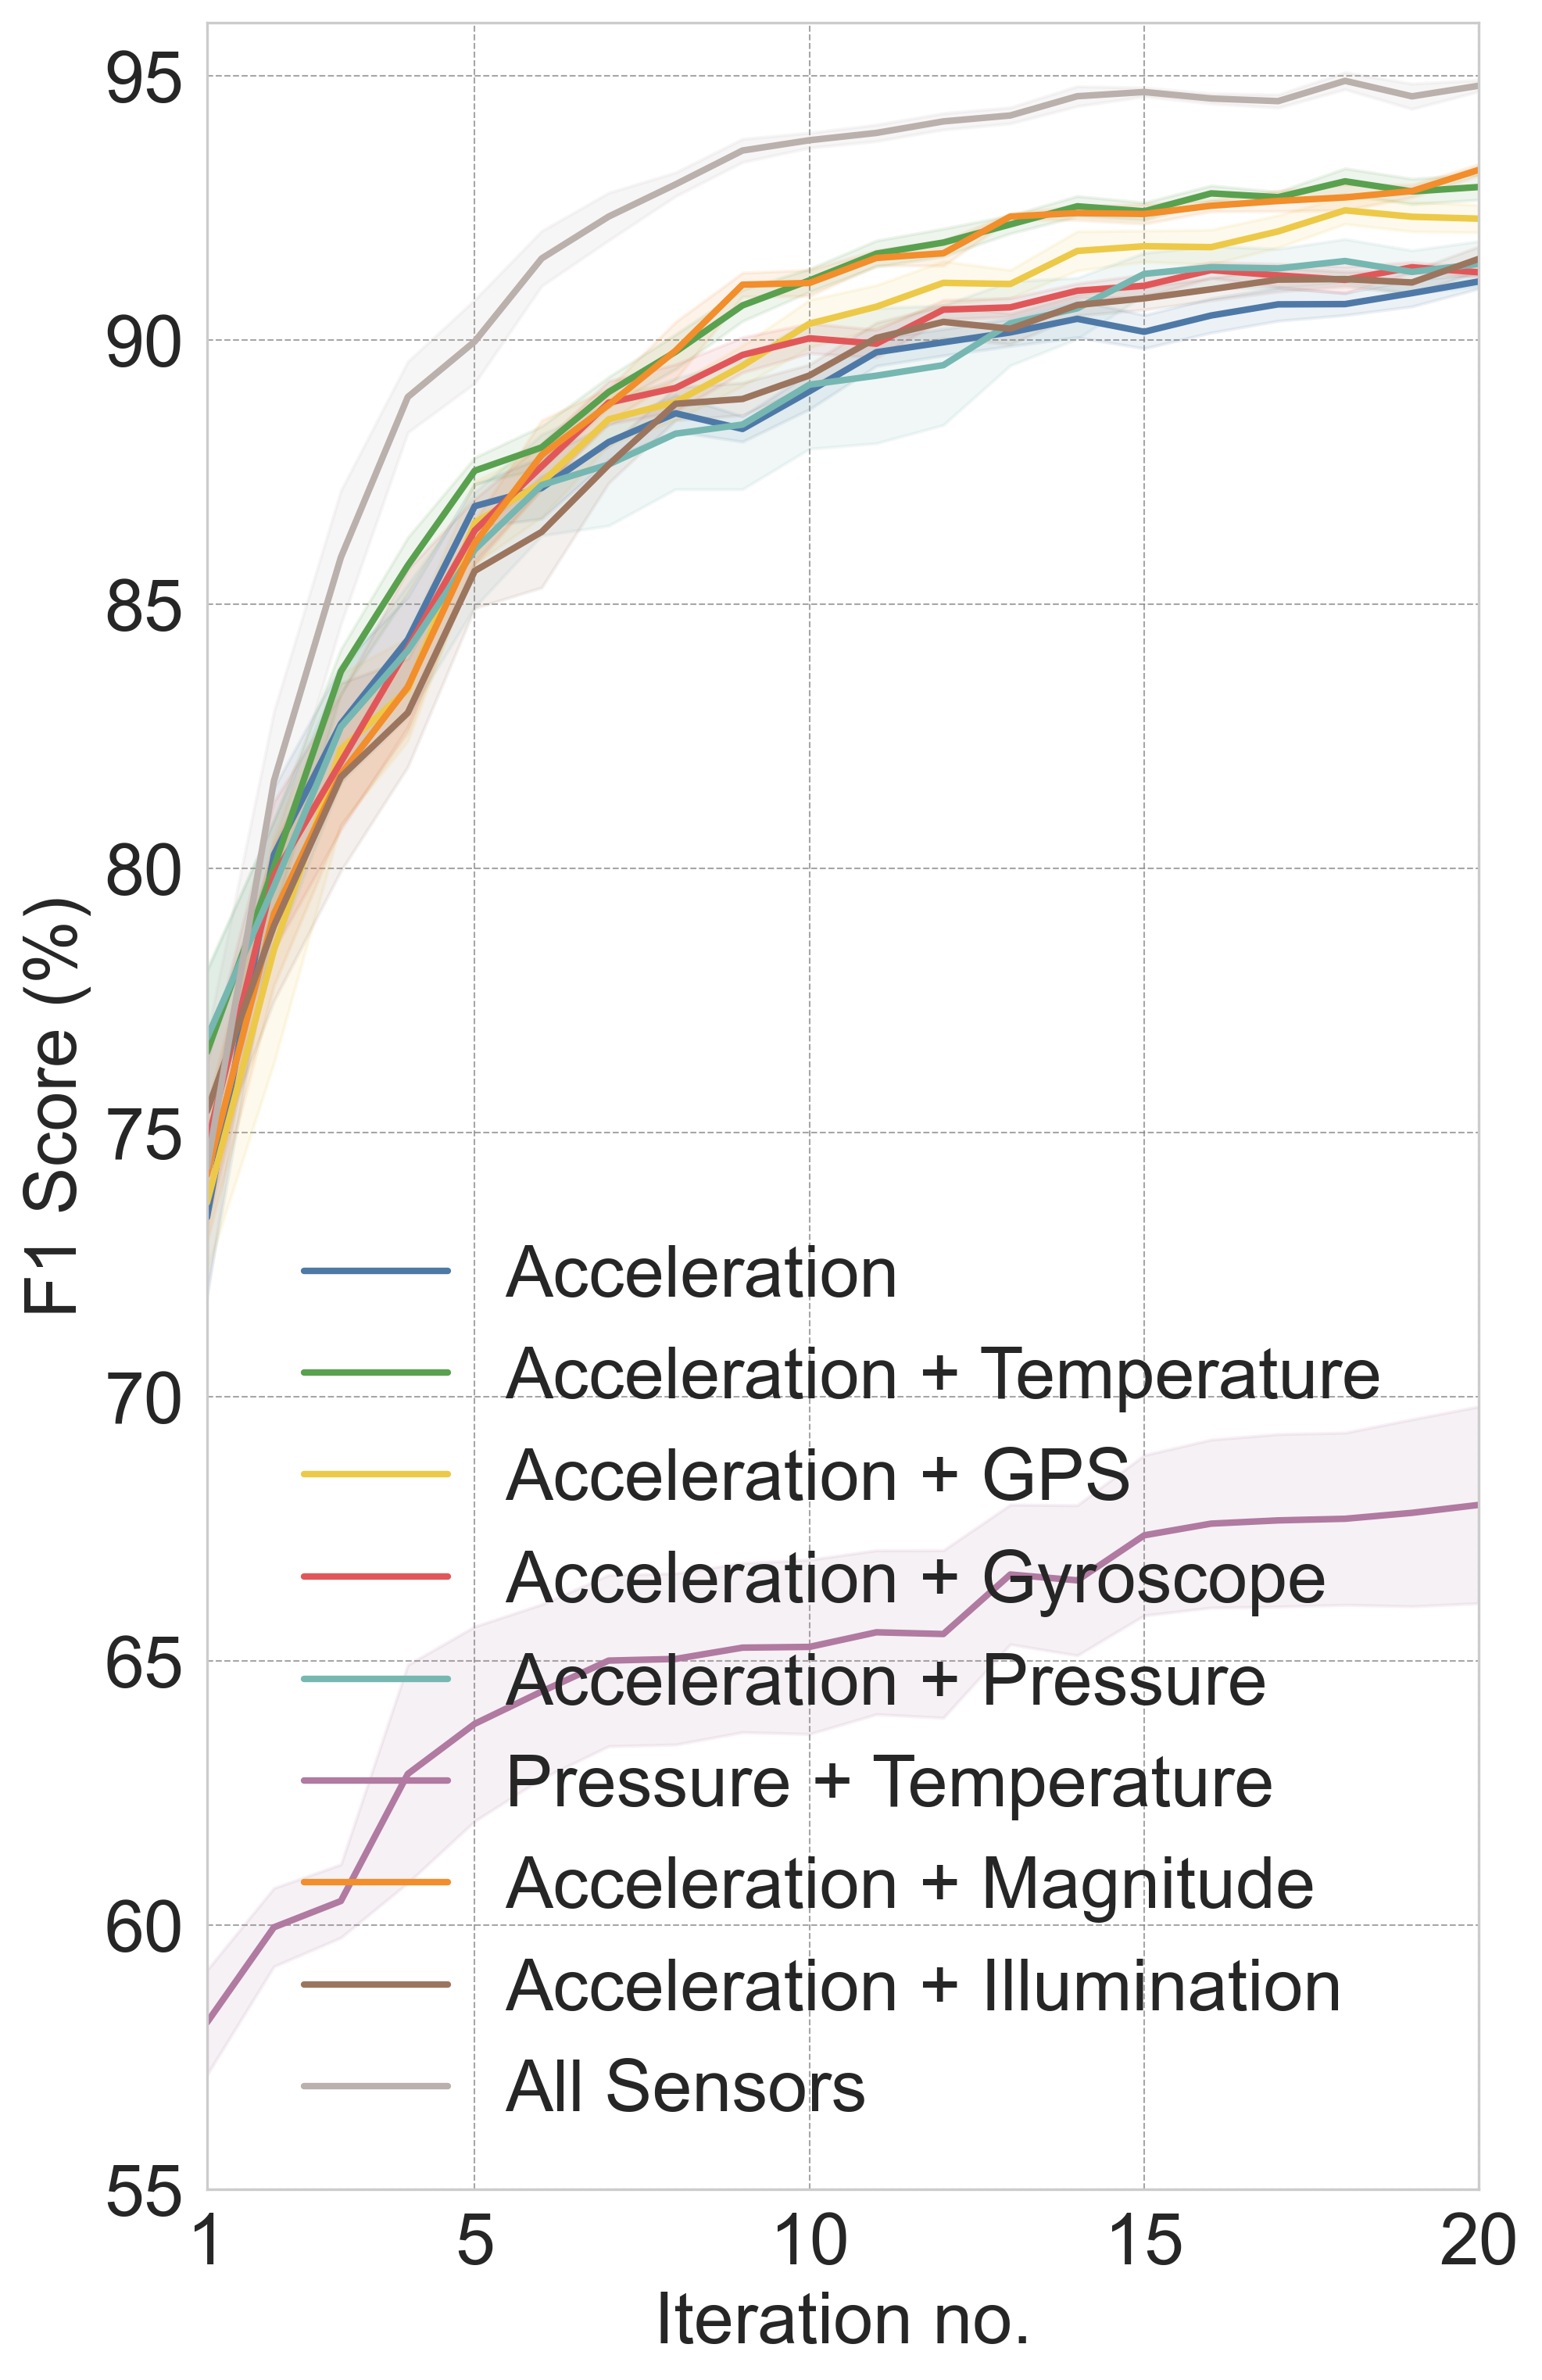

In [12]:
num_iterations = 20
# num_samples = 100  # 每次迭代预测的样本数
classes = [0, 1, 2, 3, 4, 5, 6, 7, 8]  # 5 个类别
# classes = [0, 1, 2, 3, 4]  # 5 个类别

# 计算 F1 Score
f1_scores = {cls: [] for cls in classes}  # 每个类别的 F1-score
std_devs = {cls: [] for cls in classes}  # 每个类别的 F1-score

for i in range(num_iterations):
    for cls in classes:
        if cls == 3:
            f1scores = []
            for sid in range(5):
                # f1scores.append(entropy_acc[sid][i])
                y_pred = entropy_pred_label_lists[sid][i]
                y_true = entropy_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)

                f1scores.append(f1)

            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        elif cls == 4:
            f1scores = []
            for sid in range(5):
                # f1scores.append(base_acc[sid][i])
                y_pred = base_pred_label_lists[sid][i]
                y_true = base_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)
                
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        elif cls == 5:
            f1scores = []
            for sid in range(5):
                # f1scores.append(underRandom_acc[sid][i])
                y_pred = underRandom_pred_label_lists[sid][i]
                y_true = underRandom_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)

            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        elif cls == 2:
            f1scores = []
            for sid in range(5):
                # f1scores.append(overAugment_acc[sid][i])
                y_pred = overAugment_pred_label_lists[sid][i]
                y_true = overAugment_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)
                
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        elif cls == 0:
            f1scores = []
            for sid in range(5):
                # f1scores.append(repreSamp_acc[sid][i])
                y_pred = repreSamp_pred_label_lists[sid][i]
                y_true = repreSamp_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)
            
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        elif cls == 1:
            f1scores = []
            for sid in range(5):
                # f1scores.append(entropy1_acc[sid][i])
                y_pred = entropy1_pred_label_lists[sid][i]
                y_true = entropy1_true_label_lists[sid][i]
                f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
                f1scores.append(f1)
            
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        elif cls == 8:
            f1scores = []
            for sid in range(5):
                # f1scores.append(entropy1_acc[sid][i])
                y_pred = all_pred_label_lists[sid][i]
                y_true = all_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)
            
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        elif cls == 6:
            f1scores = []
            for sid in range(5):
                # f1scores.append(entropy1_acc[sid][i])
                y_pred = accmag_pred_label_lists[sid][i]
                y_true = accmag_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)
            
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        
        elif cls == 7:
            f1scores = []
            for sid in range(5):
                # f1scores.append(entropy1_acc[sid][i])
                y_pred = accillu_pred_label_lists[sid][i]
                y_true = accillu_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)
            
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        else:
            continue
            print('error')


# 画图
# fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
fig, ax = plt.subplots(figsize=(7, 12), dpi=300)

# 区分度高的9色方案（基于 Tableau 10）
colors = {
    0: "#4E79A7",  # 深蓝 - Attack
    1: "#59A14F",  # 绿色 - Investigation
    2: "#EDC948",  # 金黄 - Mount
    3: "#E15759",  # 红色 - Category 3
    4: "#76B7B2",  # 天蓝 - Category 4
    5: "#B07AA1",  # 紫色 - Category 6
    6: "#F28E2B",  # 橙色 - Category 5
    7: "#9C755F",  # 褐色 - Category 7
    8: "#BAB0AC",  # 灰色 - Category 8
}

labels = {0: 'Acceleration',
    # 0: 'Entropy Sampling',
          3: 'Acceleration + Gyroscope',
          4: 'Acceleration + Pressure',
          5: 'Pressure + Temperature',
          # 6: 'Representative Sampling',
          1: 'Acceleration + Temperature',
          2: 'Acceleration + GPS',
          6: 'Acceleration + Magnitude',
          7: 'Acceleration + Illumination',
          8: 'All Sensors',
          # 7: 'Supervised Learning Baseline',
          }

# 绘制每个类别的曲线
for cls in f1_scores:
    ax.plot(range(1, num_iterations + 1), f1_scores[cls],
            color=colors[cls], linestyle="-", label=labels[cls], linewidth=2)

    # 添加标准误差的阴影区域
    ax.fill_between(range(1, num_iterations + 1),
                    np.array(f1_scores[cls]) - std_devs[cls],
                    np.array(f1_scores[cls]) + std_devs[cls],
                    color=colors[cls], alpha=0.1)

# # 添加supervised的虚线
# file_name = 'AccelTemp__supervisebase_seed2025_epoch49_results.pkl'  # 
# result_dict = load_data(file_name)
# supervise_acc = result_dict['test_macro_f1_list']
# 
# y_pred = result_dict['test_pred_label_lists']
# y_true = result_dict['test_truth_label_lists']
# f1 = f1_score(y_true[-1], y_pred[-1], average="weighted", zero_division=0)
# 
# ax.axhline(y=f1*100,
#            color='grey', linestyle="--", label=labels[7], linewidth=1.5)

# 标注轴标签
ax.set_xlabel("Iteration no.", fontsize=22)
ax.set_ylabel("F1 Score (%)", fontsize=22)
# ax.set_xticklabels([])  # 隐藏 X 轴标签
# ax.set_xticks([1, 5, 10, 15, 20, 25, 30])  # 设置刻度位置
# ax.set_xticklabels(["1", "5", "10", "15", "20", "25", "30"])  # 设置刻度标签
ax.tick_params(axis='y', labelsize=22)  # 设置y轴刻度字体大小
ax.set_xticks([1, 5, 10, 15, 20])  # 设置刻度位置
ax.set_xticklabels(["1", "5", "10", "15", "20"], fontsize=22)  # 设置刻度标签

# 网格线优化
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, color="gray")
ax.set_xlim(1, num_iterations)
ax.set_ylim(55, 96)
# 添加图例
ax.legend(frameon=False, fontsize=22)

plt.show()

### 时长对比

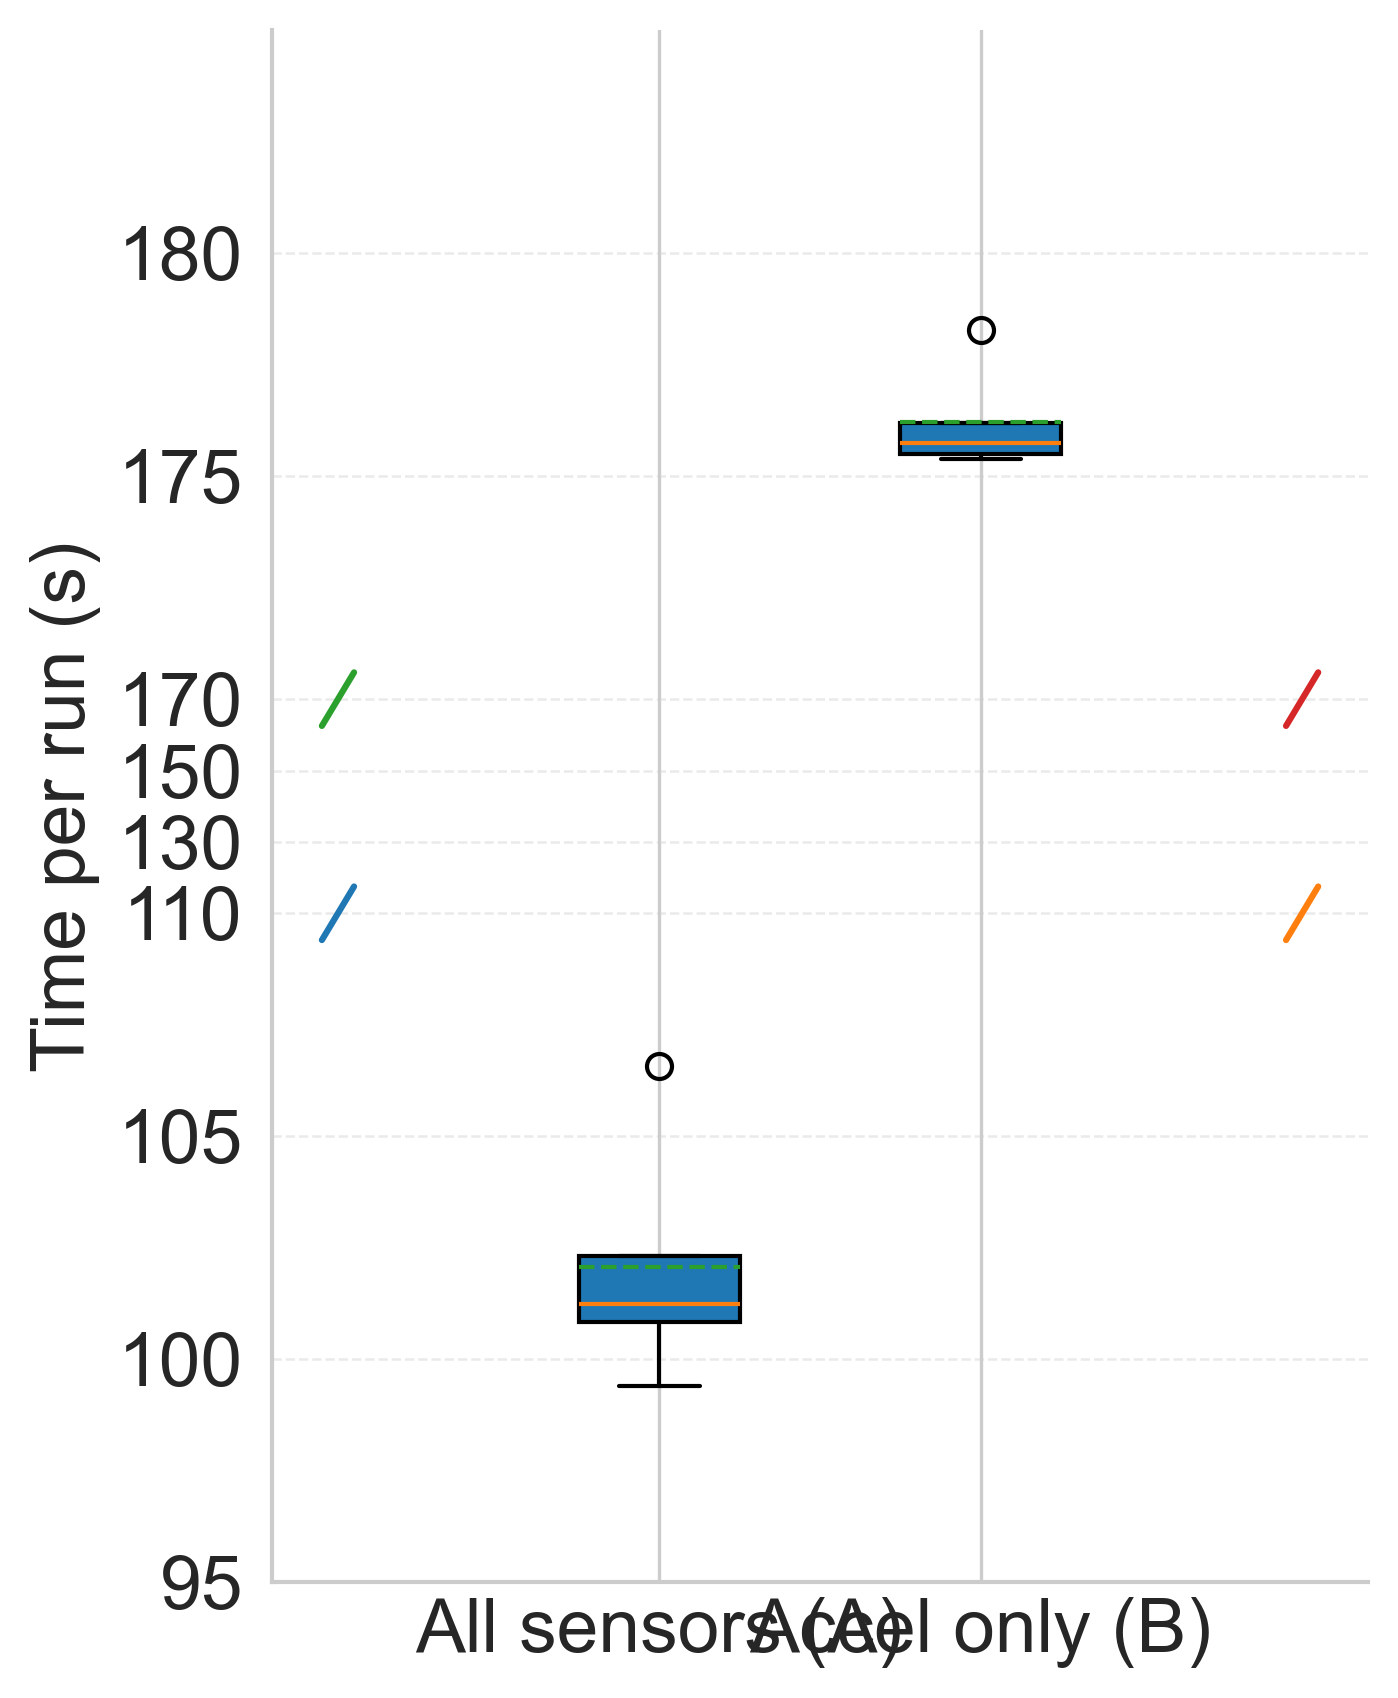

In [18]:
# # Portrait boxplot with stronger compression between 110–170s and y-axis starting at 95s.
# import numpy as np
# import matplotlib.pyplot as plt

# Data
A = np.array([176.198, 178.272, 175.503, 175.732, 175.377])  # All sensors
B = np.array([106.572, 101.244, 100.841, 99.408, 102.321])   # Accel only

mean_diff = (A - B).mean()

# Piecewise-linear squash parameters (stronger compression)
a, b, k = 110.0, 170.0, 0.08  # compress [110,170] to 8% of its height

def squash_y(y):
    y = np.asarray(y, dtype=float)
    out = y.copy()
    m1 = y <= a
    m2 = (y > a) & (y <= b)
    m3 = y > b
    out[m1] = y[m1]
    out[m2] = a + k * (y[m2] - a)
    out[m3] = a + k * (b - a) + (y[m3] - b)
    return out

def squash_tick_positions(vals):
    return [float(squash_y(v)) for v in vals]

# Transform data
A_t = squash_y(A)
B_t = squash_y(B)

# Figure: short x, long y
plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "axes.linewidth": 1.0,
})

fig = plt.figure(figsize=(5, 6), dpi=300)  # portrait
ax = plt.gca()

# Boxplot on transformed data
ax.boxplot([B_t, A_t],
# ax.boxplot([A_t, B_t],
           labels=['All sensors (A)', 'Accel only (B)'],
           widths=0.5,
           showmeans=True,
           meanline=True,
           patch_artist=True)

# Y ticks labeled with original values; start from 95
yticks_raw = [95, 100, 105, 110, 130, 150, 170, 175, 180]
ax.set_yticks(squash_tick_positions(yticks_raw))
ax.set_yticklabels([str(v) for v in yticks_raw])

# Labels/title
ax.set_ylabel('Time per run (s)')
# ax.set_title(f'Runtime across random seeds — mean Δ = {mean_diff:.2f} s')

# break marks at a and b
for y in [a, b]:
    y_t = float(squash_y(y))
    ax.plot([-0.05, 0.05], [y_t-0.6, y_t+0.6], transform=ax.transData, clip_on=False)
    ax.plot([2.95, 3.05], [y_t-0.6, y_t+0.6], transform=ax.transData, clip_on=False)

# Minimal look
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='x', length=0)
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.4)

# y-limits from 95 to 185 (transformed)
lo, hi = 95.0, 185.0
ax.set_ylim(squash_y(lo), squash_y(hi))

fig.tight_layout()

plt.show()
# svg_path = "/mnt/data/runtime_boxplot_portrait_squash_v2.svg"
# pdf_path = "/mnt/data/runtime_boxplot_portrait_squash_v2.pdf"
# fig.savefig(svg_path, bbox_inches='tight')
# fig.savefig(pdf_path, bbox_inches='tight')
# 
# svg_path, pdf_path


# 对两种组合，分别画不同activity的f1 score

In [18]:
# accel和accel+temperature


entropy_acc = []
entropy_pred_label_lists, entropy_true_label_lists, entropy_selected_labels_list = [], [], []
entropy_ari_list, entropy_nmi_list, entropy_fmi_list = [], [], []
entropy_silhouette_list, entropy_label_data_list, entropy_unlabel_data_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'AccelTemp__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid 
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    entropy_acc.append(result_dict['test_micro_f1_list'])
    entropy_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    entropy_true_label_lists.append(result_dict2['test_truth_label_lists'])

num_iterations = 20
classes = [0, 1, 2, 3, 4]  # 5 个类别

labels = labeldict_findstr

# 计算 F1 Score
f1_scores = {cls: [] for cls in classes}  # 每个类别的 F1-score
std_devs = {cls: [] for cls in classes}  # 每个类别的 F1-score
for i in range(num_iterations):
    for cls in classes: # number of classes
        tmpscore = []
        for sid in range(5):  # random seeds
            y_pred = entropy_pred_label_lists[sid][i][0]
            y_true = entropy_true_label_lists[sid][i][0]
            if cls in y_true:  # 确保类别存在
                f1 = f1_score(y_true, y_pred, labels=[cls], average="weighted", zero_division=0)
            else:
                f1 = 0.0  # 避免计算错误
            tmpscore.append(f1)
        avg_f = np.average(tmpscore)
        sem_f = np.std(tmpscore) / np.sqrt(len(tmpscore) + 1e-9)
        f1_scores[cls].append(avg_f * 100)
        std_devs[cls].append(sem_f * 100)

In [19]:
# accel和accel+temperature

entropy1_acc = []
entropy1_pred_label_lists, entropy1_true_label_lists, entropy1_selected_labels_list = [], [], []
for sid in [30,31,32,33,34]:
    file_name = 'Accel__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid 
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    entropy1_acc.append(result_dict['test_micro_f1_list'])
    entropy1_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    entropy1_true_label_lists.append(result_dict2['test_truth_label_lists'])

num_iterations = 20
classes = [0, 1, 2, 3, 4]  # 5 个类别

labels = labeldict_findstr

# 计算 F1 Score
f2_scores = {cls: [] for cls in classes}  # 每个类别的 F1-score
std2_devs = {cls: [] for cls in classes}  # 每个类别的 F1-score
for i in range(num_iterations):
    for cls in classes: # number of classes
        tmpscore = []
        for sid in range(5):  # random seeds
            y_pred = entropy1_pred_label_lists[sid][i][0]
            y_true = entropy1_true_label_lists[sid][i][0]
            if cls in y_true:  # 确保类别存在
                f1 = f1_score(y_true, y_pred, labels=[cls], average="weighted", zero_division=0)
            else:
                f1 = 0.0  # 避免计算错误
            tmpscore.append(f1)
        avg_f = np.average(tmpscore)
        sem_f = np.std(tmpscore) / np.sqrt(len(tmpscore) + 1e-9)
        f2_scores[cls].append(avg_f * 100)
        std2_devs[cls].append(sem_f * 100)

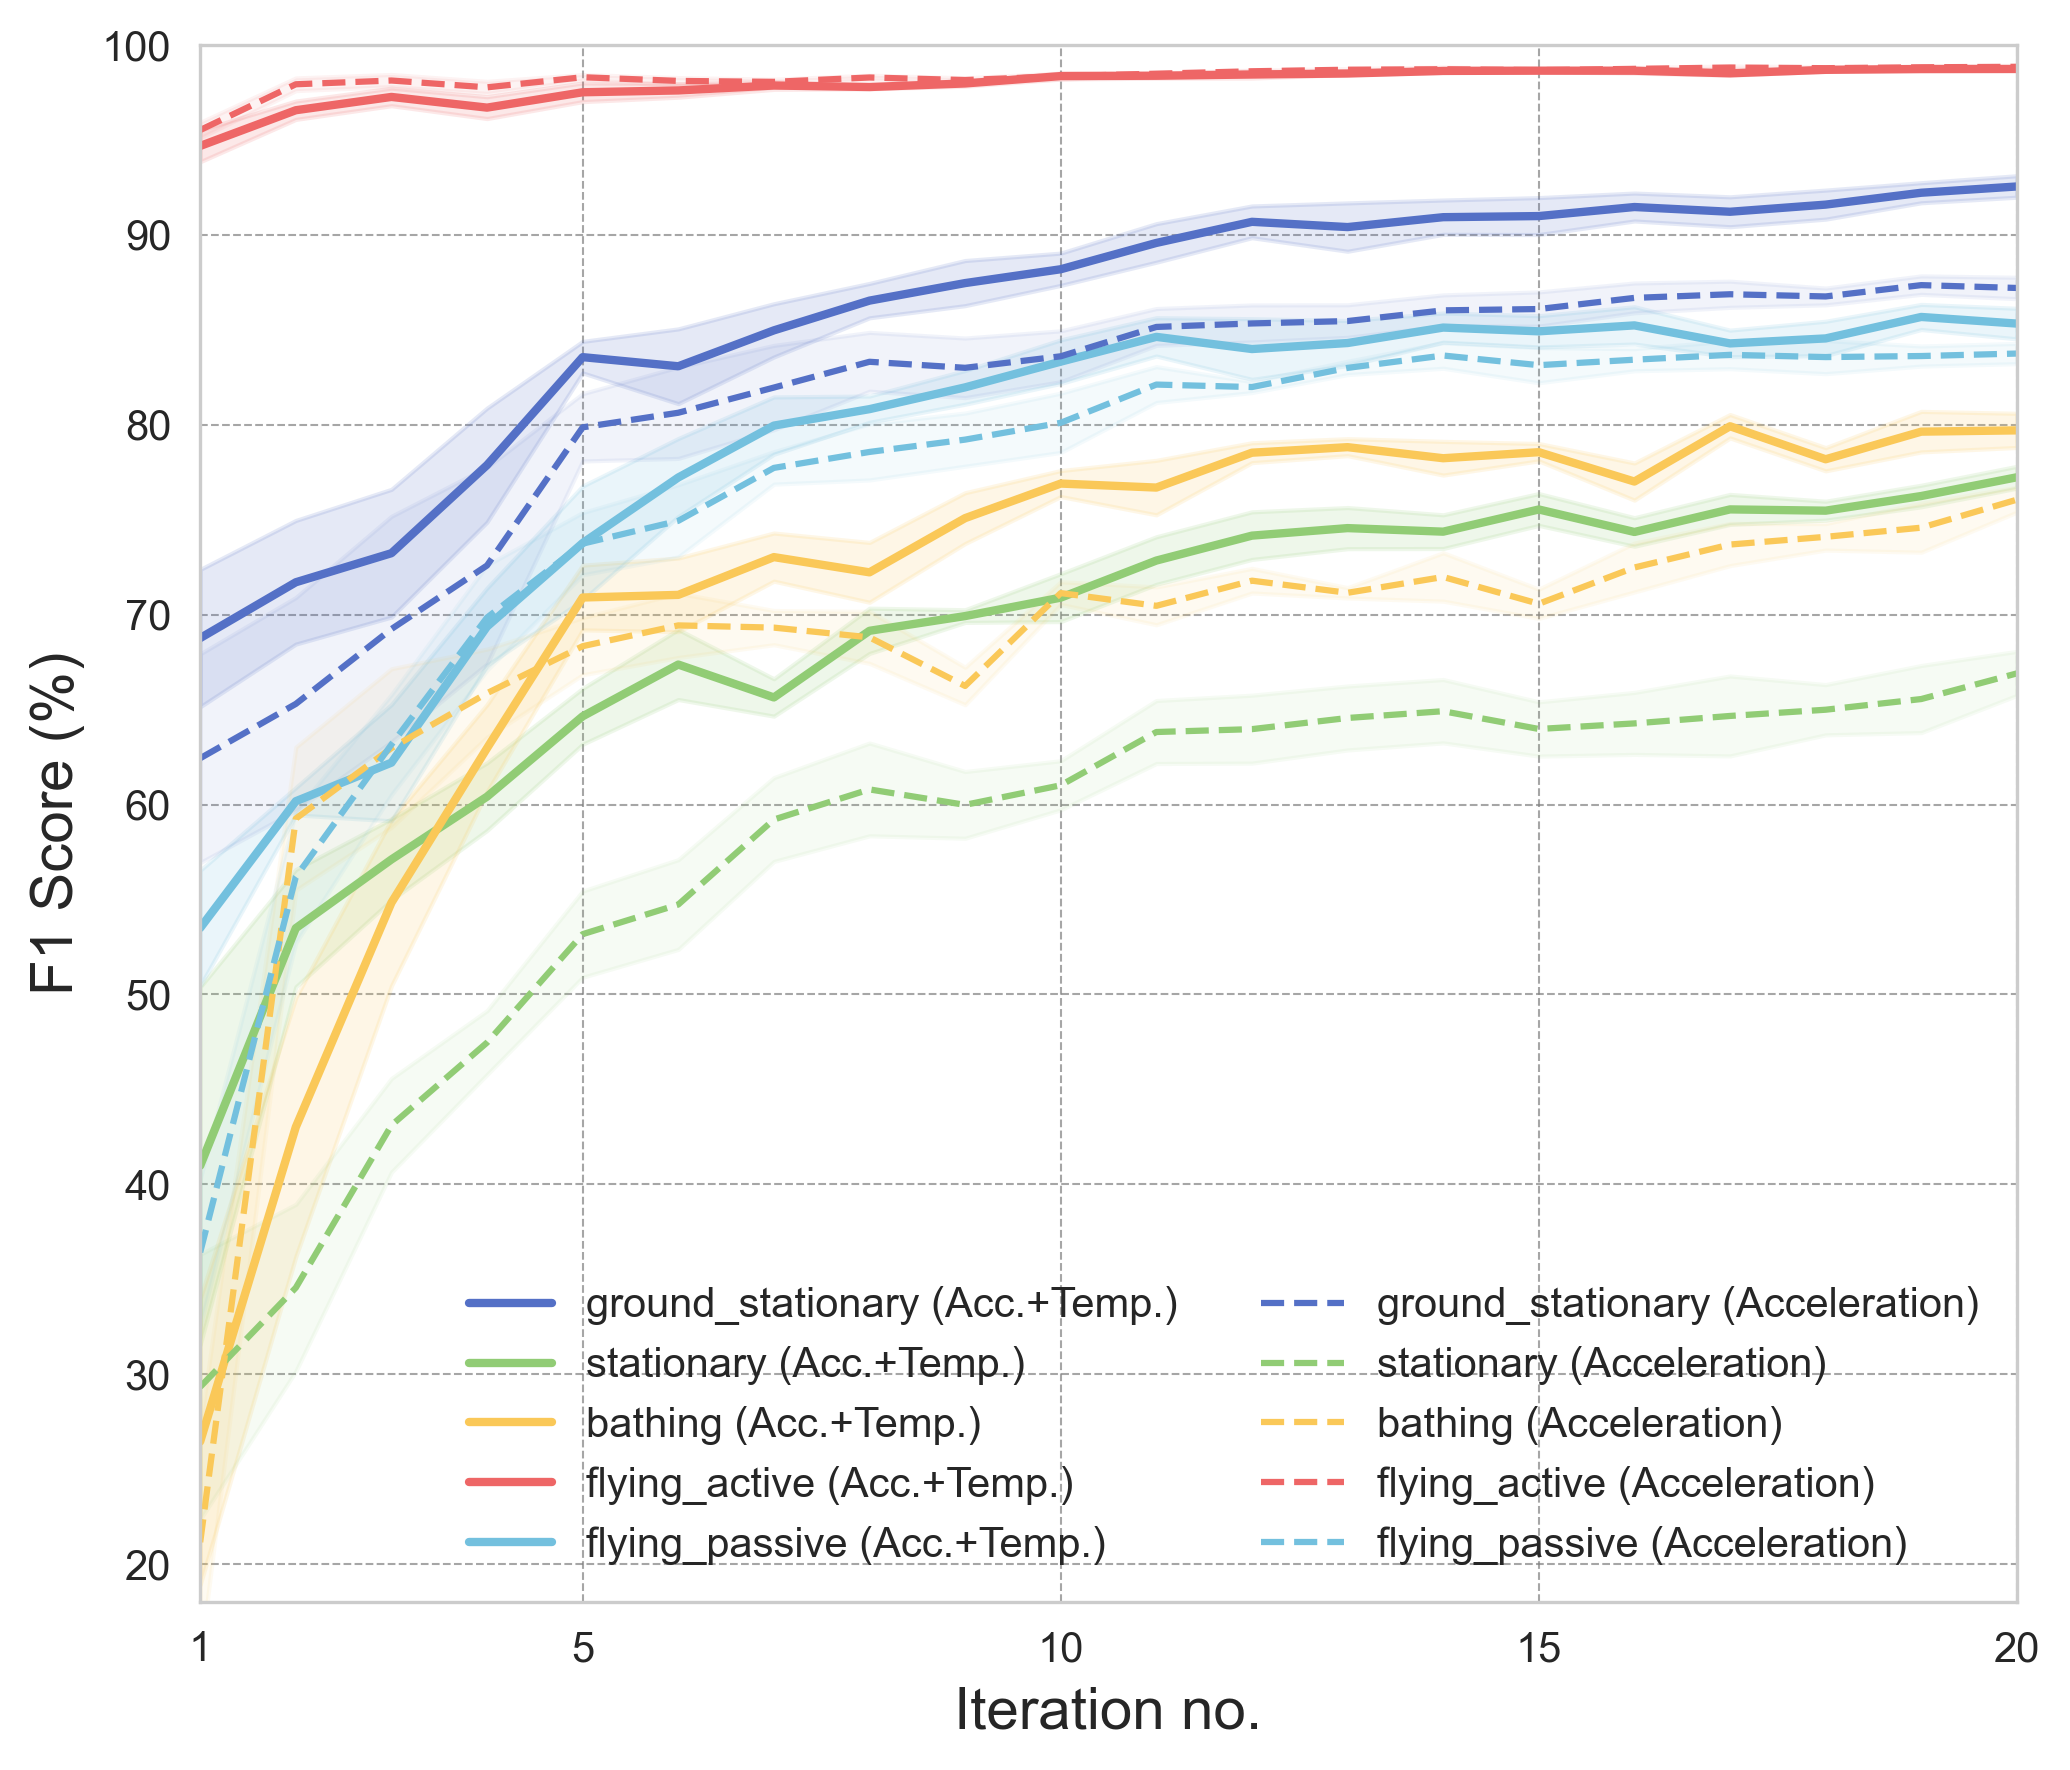

In [33]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
# fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# 颜色匹配图例
colors = {
    0: "#5470C6",  # 深蓝 - Attack
    1: "#91CC75",  # 绿色 - Investigation
    2: "#FAC858",  # 金黄 - Mount
    3: "#EE6666",  # 红色 - Category 3
    4: "#73C0DE",  # 天蓝 - Category 4
    5: "#FFB74D",  # 橙色 - Category 5
    6: "#9C27B0",  # 紫色 - Category 6
}


# 绘制每个类别的曲线
for cls in f1_scores:
    ax.plot(range(1, num_iterations + 1), f1_scores[cls],
            color=colors[cls], linestyle="-", label=labels[cls]+str(' (Acc.+Temp.)'), linewidth=2)
    # 添加标准误差的阴影区域
    ax.fill_between(range(1, num_iterations + 1),
                    np.array(f1_scores[cls]) - std_devs[cls],
                    np.array(f1_scores[cls]) + std_devs[cls],
                    color=colors[cls], alpha=0.15)
#     
# for cls in f1_scores2:    
#     ax.axhline(y=f1_scores2[cls][-1],
#                color=colors[cls], linestyle="--", label=labels[cls]+str(' (Supervised)'), linewidth=1.5)

for cls in f2_scores:
    ax.plot(range(1, num_iterations + 1), f2_scores[cls],
            color=colors[cls], linestyle="--", label=labels[cls]+str(' (Acceleration)'), linewidth=1.5)
    # 添加标准误差的阴影区域
    ax.fill_between(range(1, num_iterations + 1),
                    np.array(f2_scores[cls]) - std2_devs[cls],
                    np.array(f2_scores[cls]) + std2_devs[cls],
                    color=colors[cls], alpha=0.08)
    
# 图表美化
ax.set_xlabel("Iteration no.", fontsize=14)
ax.set_ylabel("F1 Score (%)", fontsize=14)
ax.set_xticks([1, 5, 10, 15, 20])
ax.set_xticklabels(["1", "5", "10", "15", "20"])  # 设置刻度标签
ax.set_xlim(1, num_iterations)
ax.set_ylim(18, 100)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, color="gray")

# 图例美化
ax.legend(frameon=False, fontsize=10, ncol=2)
plt.tight_layout()

## accel+gps vs accel

In [50]:
# accel和accel+temperature


entropy_acc = []
entropy_pred_label_lists, entropy_true_label_lists, entropy_selected_labels_list = [], [], []
entropy_ari_list, entropy_nmi_list, entropy_fmi_list = [], [], []
entropy_silhouette_list, entropy_label_data_list, entropy_unlabel_data_list = [], [], []
for sid in [30,31,32,33,34]:
    file_name = 'AccelGyro__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid 
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    entropy_acc.append(result_dict['test_micro_f1_list'])
    entropy_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    entropy_true_label_lists.append(result_dict2['test_truth_label_lists'])

num_iterations = 20
classes = [0, 1, 2, 3, 4]  # 5 个类别

labels = labeldict_findstr

# 计算 F1 Score
f1_scores = {cls: [] for cls in classes}  # 每个类别的 F1-score
std_devs = {cls: [] for cls in classes}  # 每个类别的 F1-score
for i in range(num_iterations):
    for cls in classes: # number of classes
        tmpscore = []
        for sid in range(5):  # random seeds
            y_pred = entropy_pred_label_lists[sid][i][0]
            y_true = entropy_true_label_lists[sid][i][0]
            if cls in y_true:  # 确保类别存在
                f1 = f1_score(y_true, y_pred, labels=[cls], average="weighted", zero_division=0)
            else:
                f1 = 0.0  # 避免计算错误
            tmpscore.append(f1)
        avg_f = np.average(tmpscore)
        sem_f = np.std(tmpscore) / np.sqrt(len(tmpscore) + 1e-9)
        f1_scores[cls].append(avg_f * 100)
        std_devs[cls].append(sem_f * 100)

In [51]:
# accel和accel+temperature

entropy1_acc = []
entropy1_pred_label_lists, entropy1_true_label_lists, entropy1_selected_labels_list = [], [], []
for sid in [30,31,32,33,34]:
    file_name = 'Accel__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid 
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    entropy1_acc.append(result_dict['test_micro_f1_list'])
    entropy1_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    entropy1_true_label_lists.append(result_dict2['test_truth_label_lists'])

num_iterations = 20
classes = [0, 1, 2, 3, 4]  # 5 个类别

labels = labeldict_findstr

# 计算 F1 Score
f2_scores = {cls: [] for cls in classes}  # 每个类别的 F1-score
std2_devs = {cls: [] for cls in classes}  # 每个类别的 F1-score
for i in range(num_iterations):
    for cls in classes: # number of classes
        tmpscore = []
        for sid in range(5):  # random seeds
            y_pred = entropy1_pred_label_lists[sid][i][0]
            y_true = entropy1_true_label_lists[sid][i][0]
            if cls in y_true:  # 确保类别存在
                f1 = f1_score(y_true, y_pred, labels=[cls], average="weighted", zero_division=0)
            else:
                f1 = 0.0  # 避免计算错误
            tmpscore.append(f1)
        avg_f = np.average(tmpscore)
        sem_f = np.std(tmpscore) / np.sqrt(len(tmpscore) + 1e-9)
        f2_scores[cls].append(avg_f * 100)
        std2_devs[cls].append(sem_f * 100)

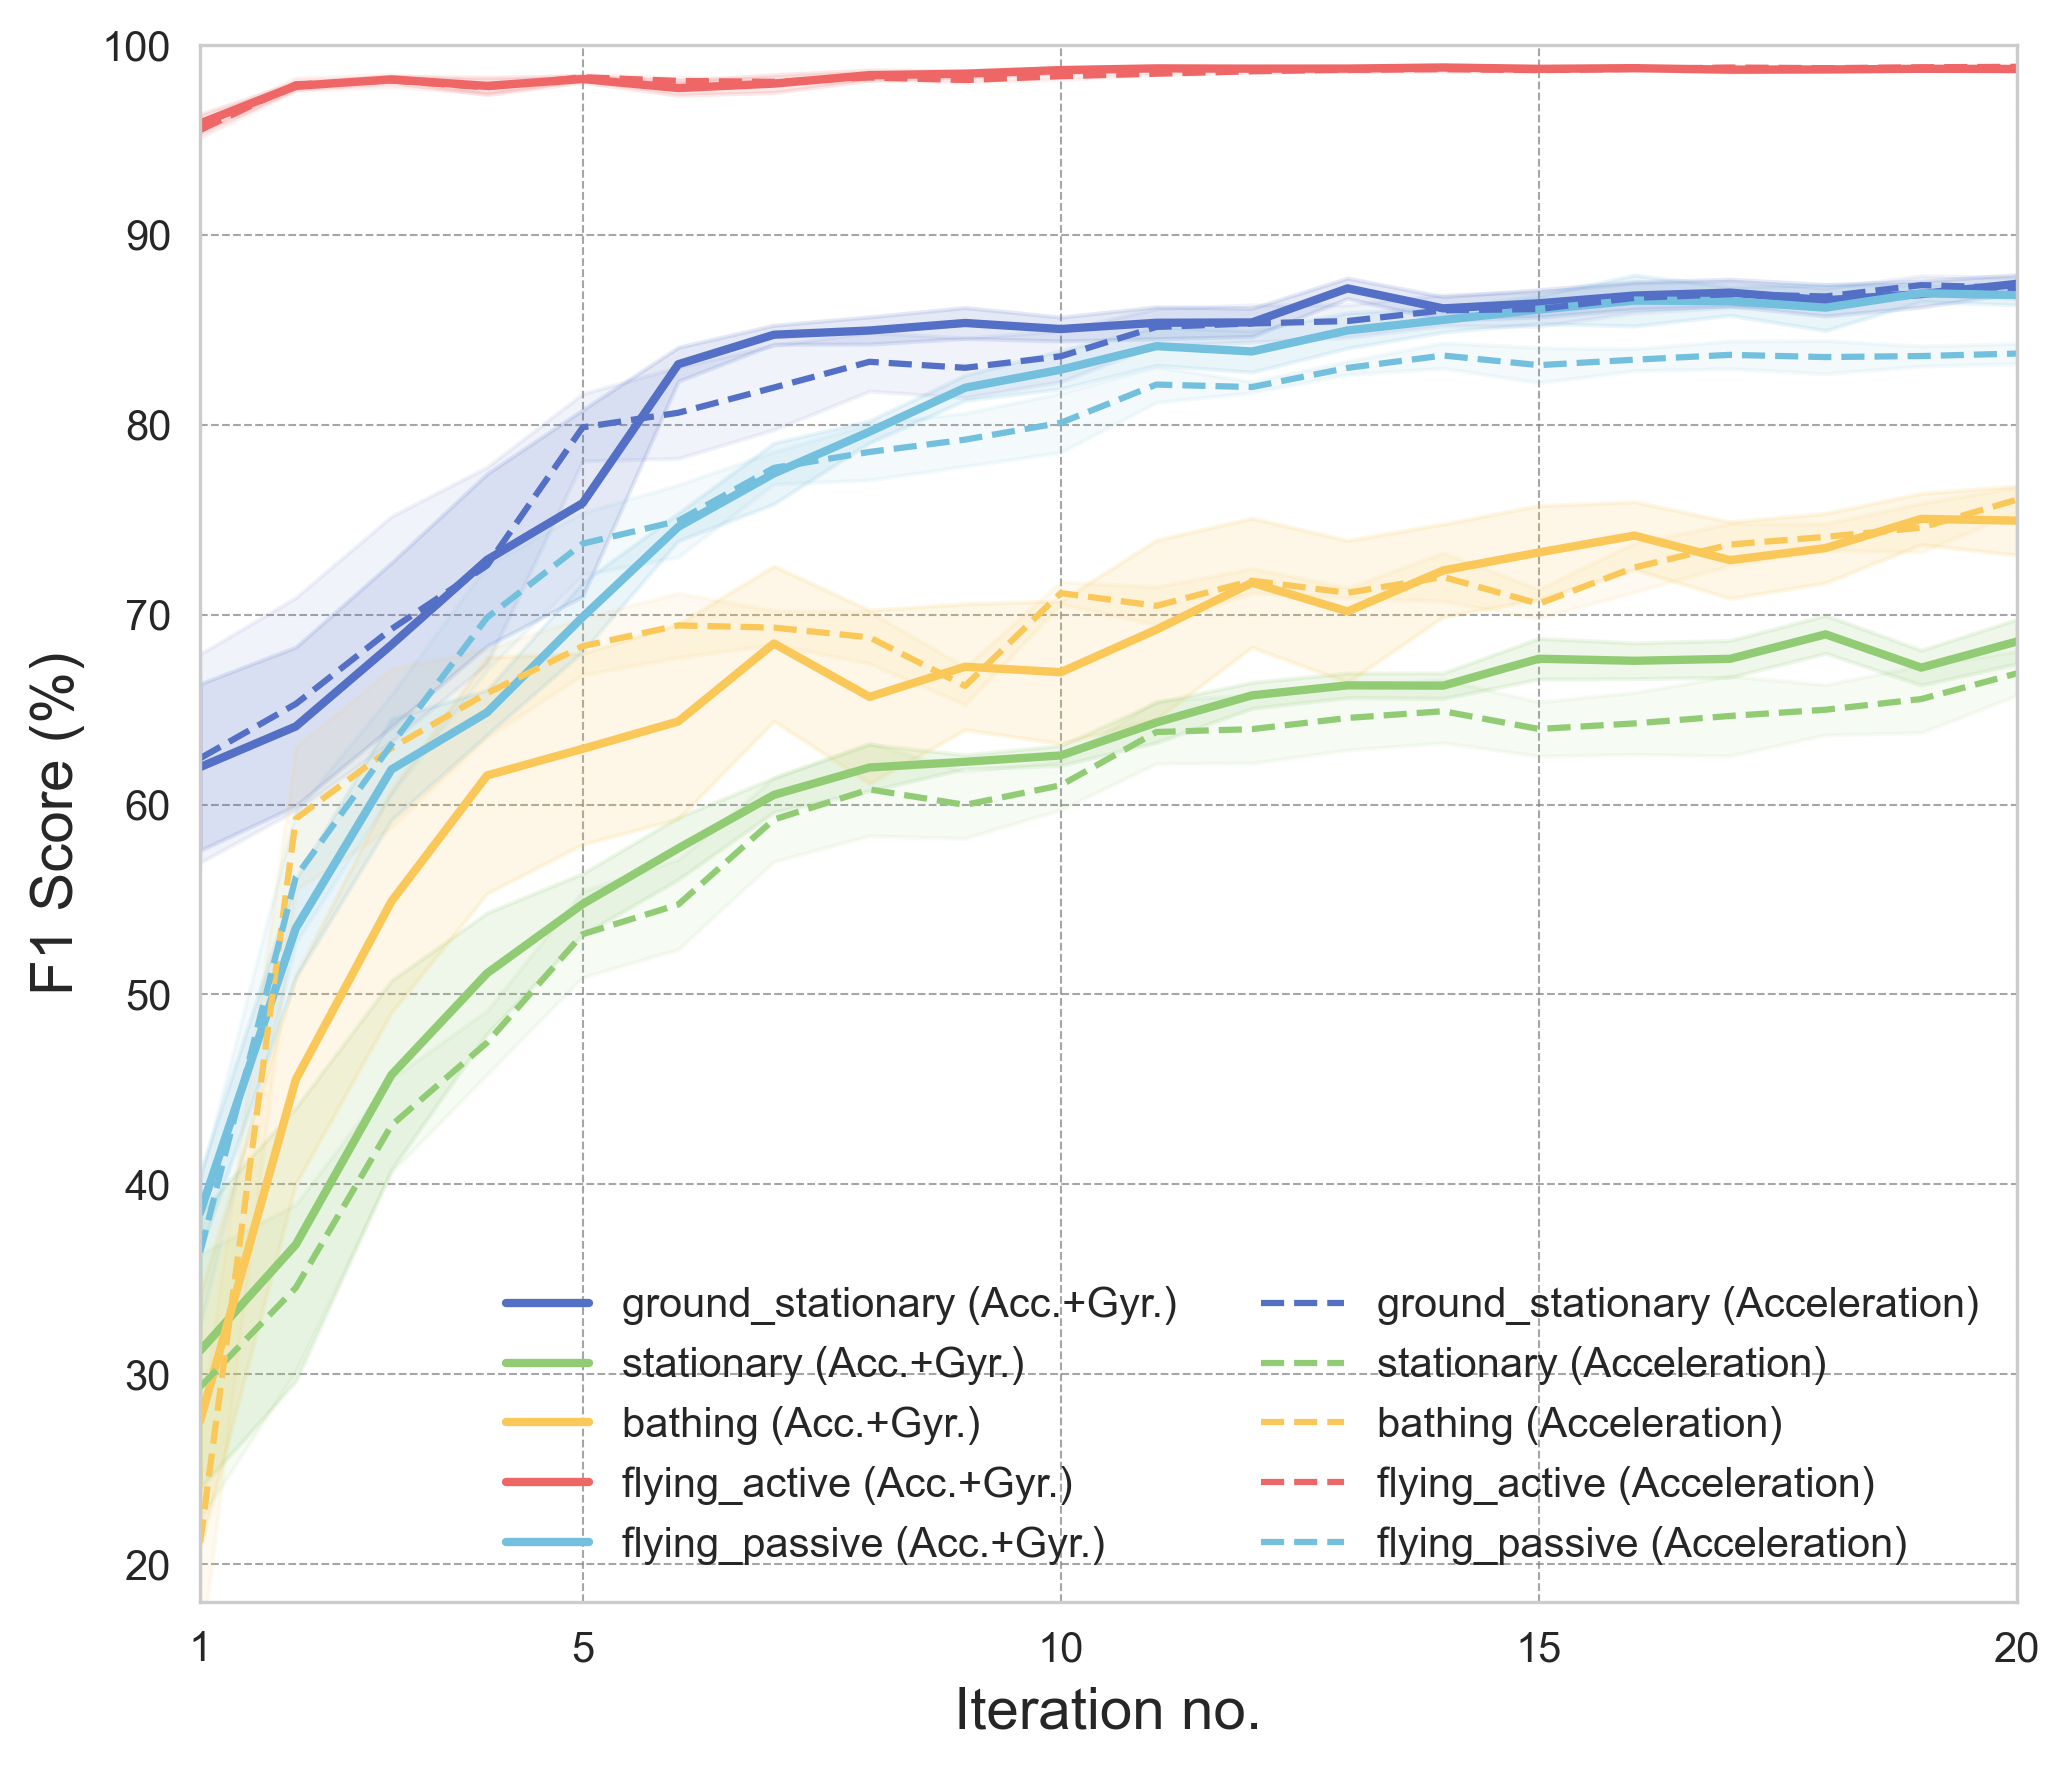

In [52]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
# fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# 颜色匹配图例
colors = {
    0: "#5470C6",  # 深蓝 - Attack
    1: "#91CC75",  # 绿色 - Investigation
    2: "#FAC858",  # 金黄 - Mount
    3: "#EE6666",  # 红色 - Category 3
    4: "#73C0DE",  # 天蓝 - Category 4
    5: "#FFB74D",  # 橙色 - Category 5
    6: "#9C27B0",  # 紫色 - Category 6
}


# 绘制每个类别的曲线
for cls in f1_scores:
    ax.plot(range(1, num_iterations + 1), f1_scores[cls],
            color=colors[cls], linestyle="-", label=labels[cls]+str(' (Acc.+Gyr.)'), linewidth=2)
    # 添加标准误差的阴影区域
    ax.fill_between(range(1, num_iterations + 1),
                    np.array(f1_scores[cls]) - std_devs[cls],
                    np.array(f1_scores[cls]) + std_devs[cls],
                    color=colors[cls], alpha=0.15)
#     
# for cls in f1_scores2:    
#     ax.axhline(y=f1_scores2[cls][-1],
#                color=colors[cls], linestyle="--", label=labels[cls]+str(' (Supervised)'), linewidth=1.5)

for cls in f2_scores:
    ax.plot(range(1, num_iterations + 1), f2_scores[cls],
            color=colors[cls], linestyle="--", label=labels[cls]+str(' (Acceleration)'), linewidth=1.5)
    # 添加标准误差的阴影区域
    ax.fill_between(range(1, num_iterations + 1),
                    np.array(f2_scores[cls]) - std2_devs[cls],
                    np.array(f2_scores[cls]) + std2_devs[cls],
                    color=colors[cls], alpha=0.08)
    
# 图表美化
ax.set_xlabel("Iteration no.", fontsize=14)
ax.set_ylabel("F1 Score (%)", fontsize=14)
ax.set_xticks([1, 5, 10, 15, 20])
ax.set_xticklabels(["1", "5", "10", "15", "20"])  # 设置刻度标签
ax.set_xlim(1, num_iterations)
ax.set_ylim(18, 100)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, color="gray")

# 图例美化
ax.legend(frameon=False, fontsize=10, ncol=2)
plt.tight_layout()
plt.show()

## accel+pressure vs accel

In [2]:
# accel和accel+pressure


entropy_acc = []
entropy_pred_label_lists, entropy_true_label_lists, entropy_selected_labels_list = [], [], []
entropy_ari_list, entropy_nmi_list, entropy_fmi_list = [], [], []
entropy_silhouette_list, entropy_label_data_list, entropy_unlabel_data_list = [], [], []
for sid in [30,31,32,33,34]:
    file_name = 'AccelPress__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid 
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    entropy_acc.append(result_dict['test_micro_f1_list'])
    entropy_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    entropy_true_label_lists.append(result_dict2['test_truth_label_lists'])

num_iterations = 20
classes = [0, 1, 2, 3, 4]  # 5 个类别

labels = labeldict_findstr

# 计算 F1 Score
f1_scores = {cls: [] for cls in classes}  # 每个类别的 F1-score
std_devs = {cls: [] for cls in classes}  # 每个类别的 F1-score
for i in range(num_iterations):
    for cls in classes: # number of classes
        tmpscore = []
        for sid in range(5):  # random seeds
            y_pred = entropy_pred_label_lists[sid][i][0]
            y_true = entropy_true_label_lists[sid][i][0]
            if cls in y_true:  # 确保类别存在
                f1 = f1_score(y_true, y_pred, labels=[cls], average="weighted", zero_division=0)
            else:
                f1 = 0.0  # 避免计算错误
            tmpscore.append(f1)
        avg_f = np.average(tmpscore)
        sem_f = np.std(tmpscore) / np.sqrt(len(tmpscore) + 1e-9)
        f1_scores[cls].append(avg_f * 100)
        std_devs[cls].append(sem_f * 100)

In [3]:
# accel和accel+temperature

entropy1_acc = []
entropy1_pred_label_lists, entropy1_true_label_lists, entropy1_selected_labels_list = [], [], []
for sid in [30,31,32,33,34]:
    file_name = 'Accel__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid 
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    entropy1_acc.append(result_dict['test_micro_f1_list'])
    entropy1_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    entropy1_true_label_lists.append(result_dict2['test_truth_label_lists'])

num_iterations = 20
classes = [0, 1, 2, 3, 4]  # 5 个类别

labels = labeldict_findstr

# 计算 F1 Score
f2_scores = {cls: [] for cls in classes}  # 每个类别的 F1-score
std2_devs = {cls: [] for cls in classes}  # 每个类别的 F1-score
for i in range(num_iterations):
    for cls in classes: # number of classes
        tmpscore = []
        for sid in range(5):  # random seeds
            y_pred = entropy1_pred_label_lists[sid][i][0]
            y_true = entropy1_true_label_lists[sid][i][0]
            if cls in y_true:  # 确保类别存在
                f1 = f1_score(y_true, y_pred, labels=[cls], average="weighted", zero_division=0)
            else:
                f1 = 0.0  # 避免计算错误
            tmpscore.append(f1)
        avg_f = np.average(tmpscore)
        sem_f = np.std(tmpscore) / np.sqrt(len(tmpscore) + 1e-9)
        f2_scores[cls].append(avg_f * 100)
        std2_devs[cls].append(sem_f * 100)

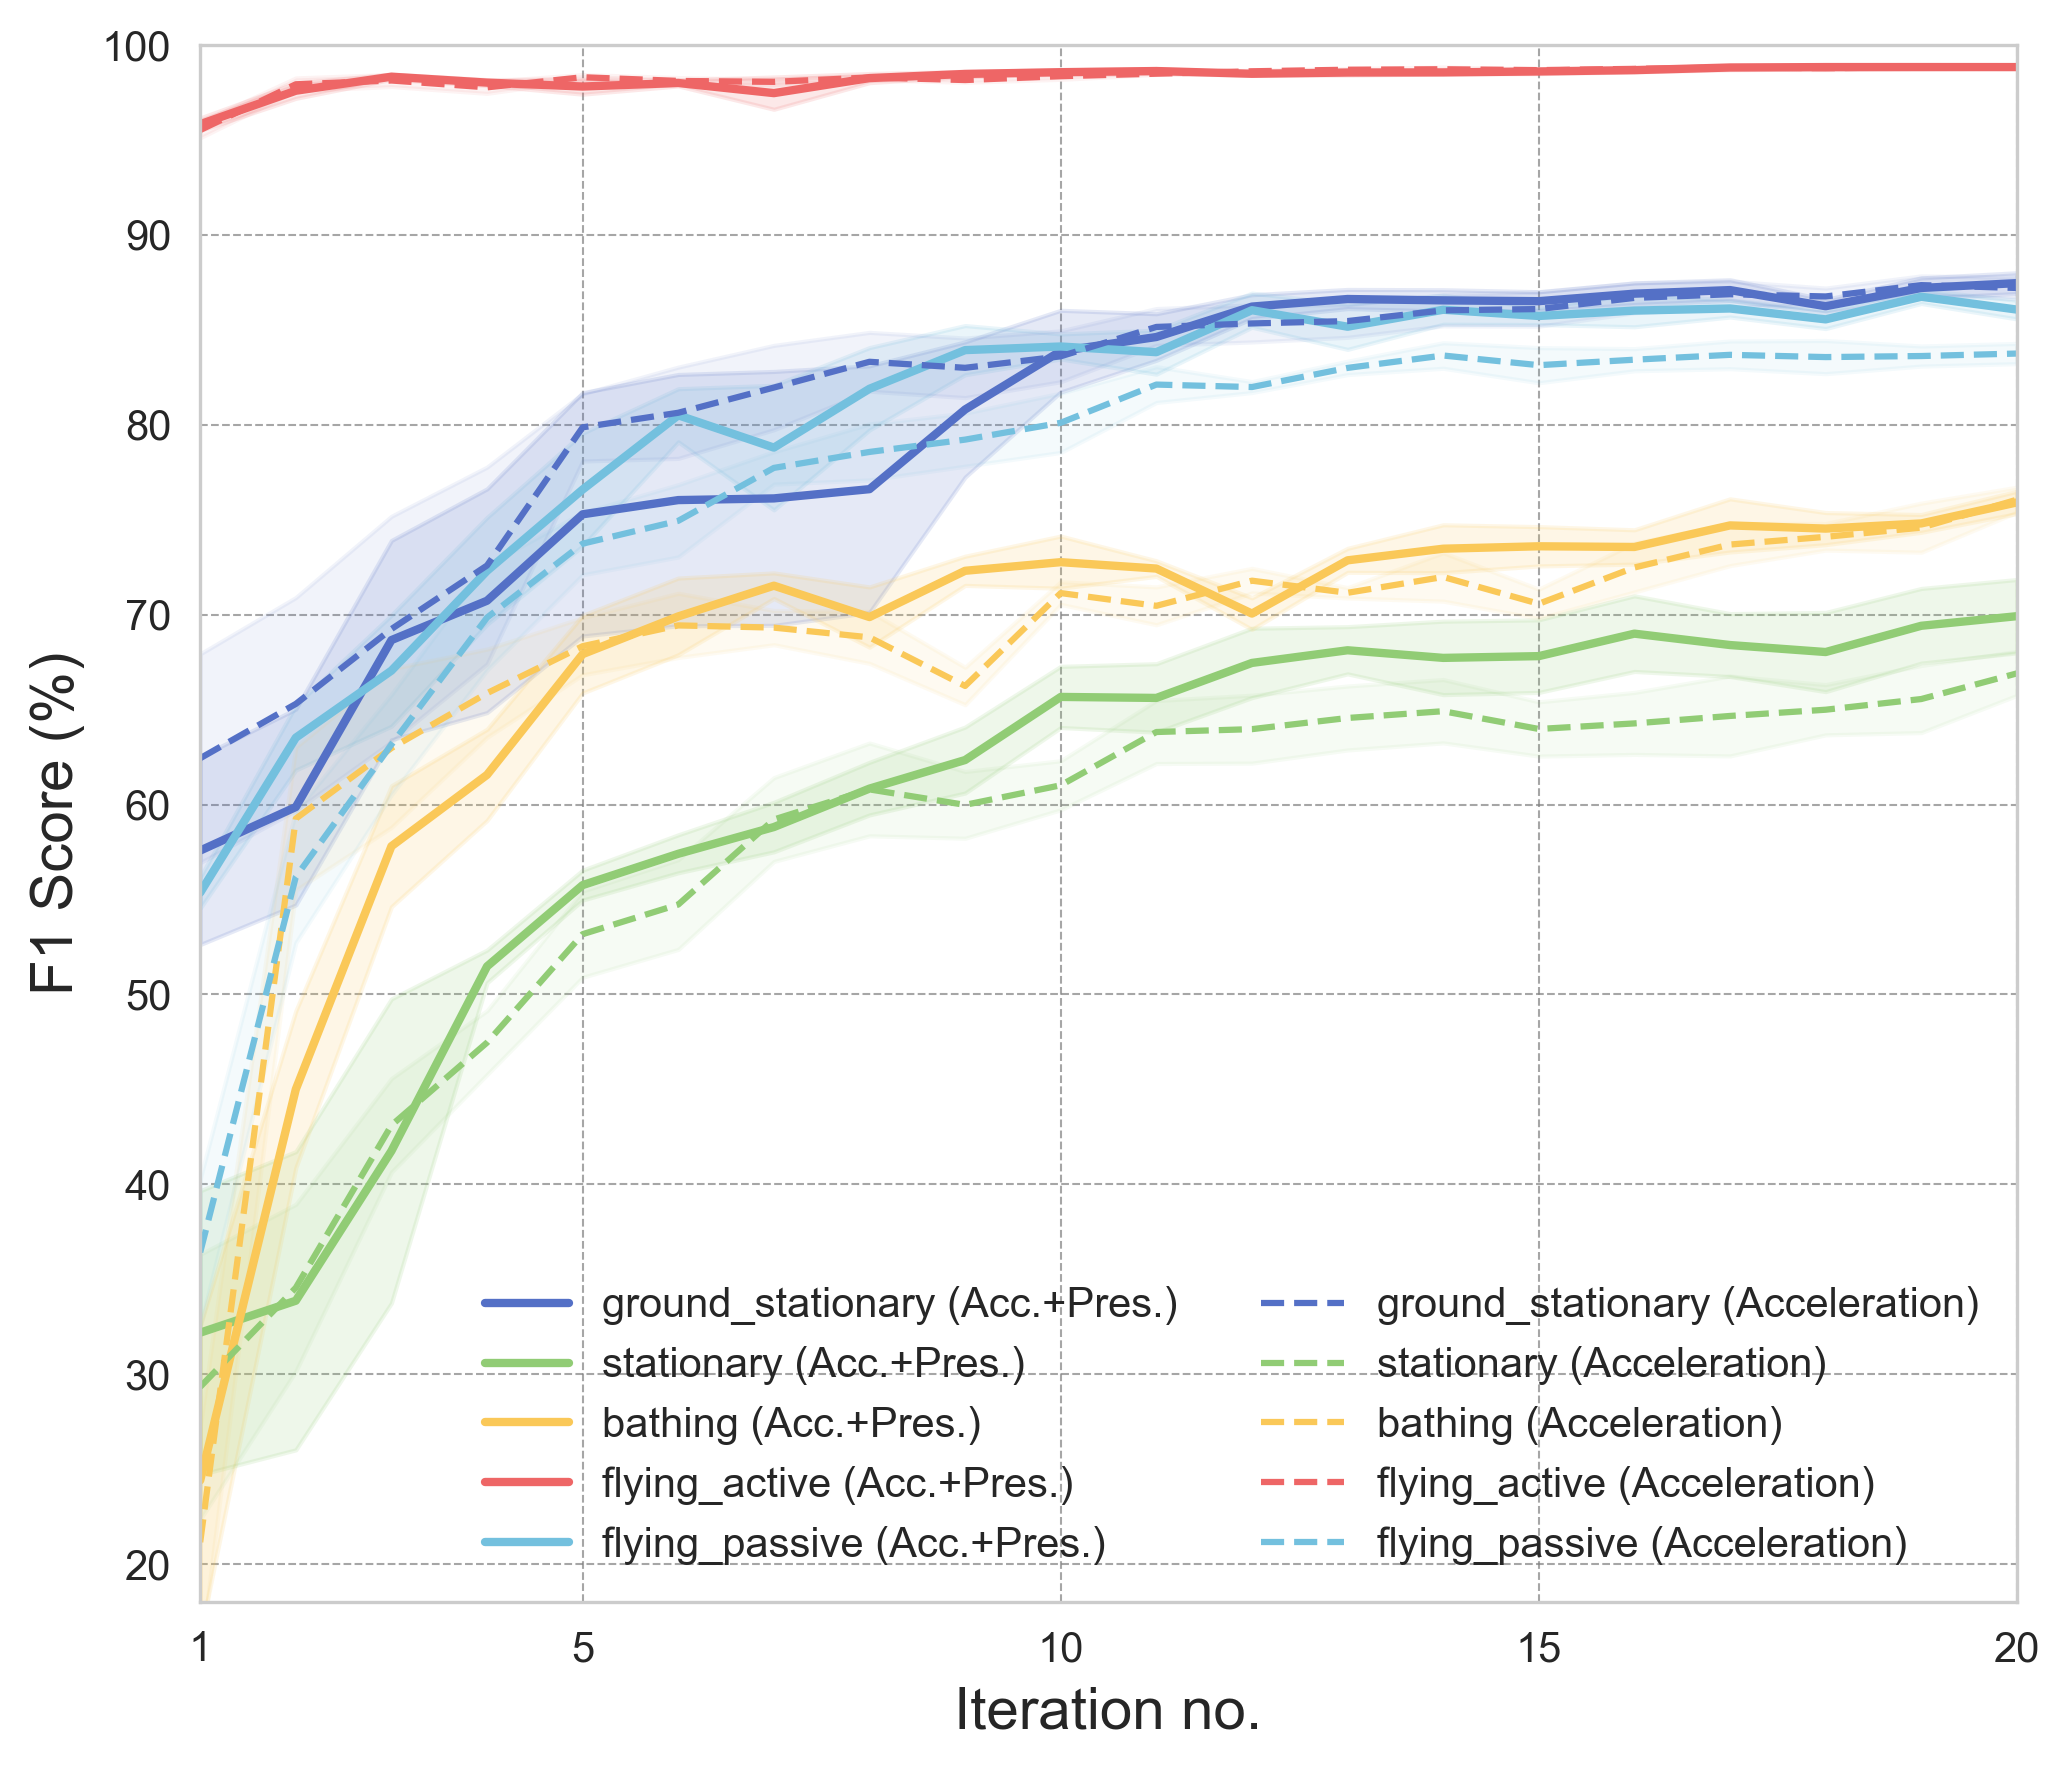

In [5]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
# fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# 颜色匹配图例
colors = {
    0: "#5470C6",  # 深蓝 - Attack
    1: "#91CC75",  # 绿色 - Investigation
    2: "#FAC858",  # 金黄 - Mount
    3: "#EE6666",  # 红色 - Category 3
    4: "#73C0DE",  # 天蓝 - Category 4
    5: "#FFB74D",  # 橙色 - Category 5
    6: "#9C27B0",  # 紫色 - Category 6
}


# 绘制每个类别的曲线
for cls in f1_scores:
    ax.plot(range(1, num_iterations + 1), f1_scores[cls],
            color=colors[cls], linestyle="-", label=labels[cls]+str(' (Acc.+Pres.)'), linewidth=2)
    # 添加标准误差的阴影区域
    ax.fill_between(range(1, num_iterations + 1),
                    np.array(f1_scores[cls]) - std_devs[cls],
                    np.array(f1_scores[cls]) + std_devs[cls],
                    color=colors[cls], alpha=0.15)
#     
# for cls in f1_scores2:    
#     ax.axhline(y=f1_scores2[cls][-1],
#                color=colors[cls], linestyle="--", label=labels[cls]+str(' (Supervised)'), linewidth=1.5)

for cls in f2_scores:
    ax.plot(range(1, num_iterations + 1), f2_scores[cls],
            color=colors[cls], linestyle="--", label=labels[cls]+str(' (Acceleration)'), linewidth=1.5)
    # 添加标准误差的阴影区域
    ax.fill_between(range(1, num_iterations + 1),
                    np.array(f2_scores[cls]) - std2_devs[cls],
                    np.array(f2_scores[cls]) + std2_devs[cls],
                    color=colors[cls], alpha=0.08)
    
# 图表美化
ax.set_xlabel("Iteration no.", fontsize=14)
ax.set_ylabel("F1 Score (%)", fontsize=14)
ax.set_xticks([1, 5, 10, 15, 20])
ax.set_xticklabels(["1", "5", "10", "15", "20"])  # 设置刻度标签
ax.set_xlim(1, num_iterations)
ax.set_ylim(18, 100)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, color="gray")

# 图例美化
ax.legend(frameon=False, fontsize=10, ncol=2)
plt.tight_layout()
plt.show()

# Fig3：对比学习和其他手法在使用Accel时的前20次迭代的F1 score

### umineko

In [26]:

root_path = r'D:\code\DeepView\deepview\calculate_results\data\umineko'

# Fig3 对比学习比较，只看accel，20次迭代F1 score
base_acc = []
f1scores = []
base_pred_label_lists, base_true_label_lists, base_selected_labels_list = [], [], []
base_ari_list, base_nmi_list, base_fmi_list = [], [], []
base_silhouette_list, base_label_data_list, base_unlabel_data_list = [], [], []
for sid in [1,2,5,10,2025,11,12,15,110,1025]:
    file_name = 'Accel__entropy_Contrast1_warm0_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    base_acc.append(result_dict['test_micro_f1_list'])
    base_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    base_true_label_lists.append(result_dict2['test_truth_label_lists'])
    
    
    y_pred = result_dict1['test_pred_label_lists'][19][0]
    y_true = result_dict2['test_truth_label_lists'][19][0]
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    f1scores.append(f1)


In [27]:


root_path = r'D:\code\DeepView\deepview\calculate_results\data\umineko'

# Fig3 对比学习比较，只看accel，20次迭代F1 score
base_acc = []
base_pred_label_lists, base_true_label_lists, base_selected_labels_list = [], [], []
base_ari_list, base_nmi_list, base_fmi_list = [], [], []
base_silhouette_list, base_label_data_list, base_unlabel_data_list = [], [], []
for sid in [1,2,5,11,12]:
# for sid in [2,11,12,15,110]:
    file_name = 'Accel__entropy_Contrast1_warm0_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    base_acc.append(result_dict['test_micro_f1_list'])
    base_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    base_true_label_lists.append(result_dict2['test_truth_label_lists'])
    

entropy_acc = []
entropy_pred_label_lists, entropy_true_label_lists, entropy_selected_labels_list = [], [], []
entropy_ari_list, entropy_nmi_list, entropy_fmi_list = [], [], []
entropy_silhouette_list, entropy_label_data_list, entropy_unlabel_data_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__entropy_Contrast1_warm20_Cepo10_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    entropy_acc.append(result_dict['test_micro_f1_list'])
    entropy_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    entropy_true_label_lists.append(result_dict2['test_truth_label_lists'])
    
    
simclr_acc = []
simclr_pred_label_lists, simclr_true_label_lists, simclr_selected_labels_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__entropy_Contrast1_SimCLR_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    simclr_acc.append(result_dict['test_micro_f1_list'])
    simclr_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    simclr_true_label_lists.append(result_dict2['test_truth_label_lists'])
    



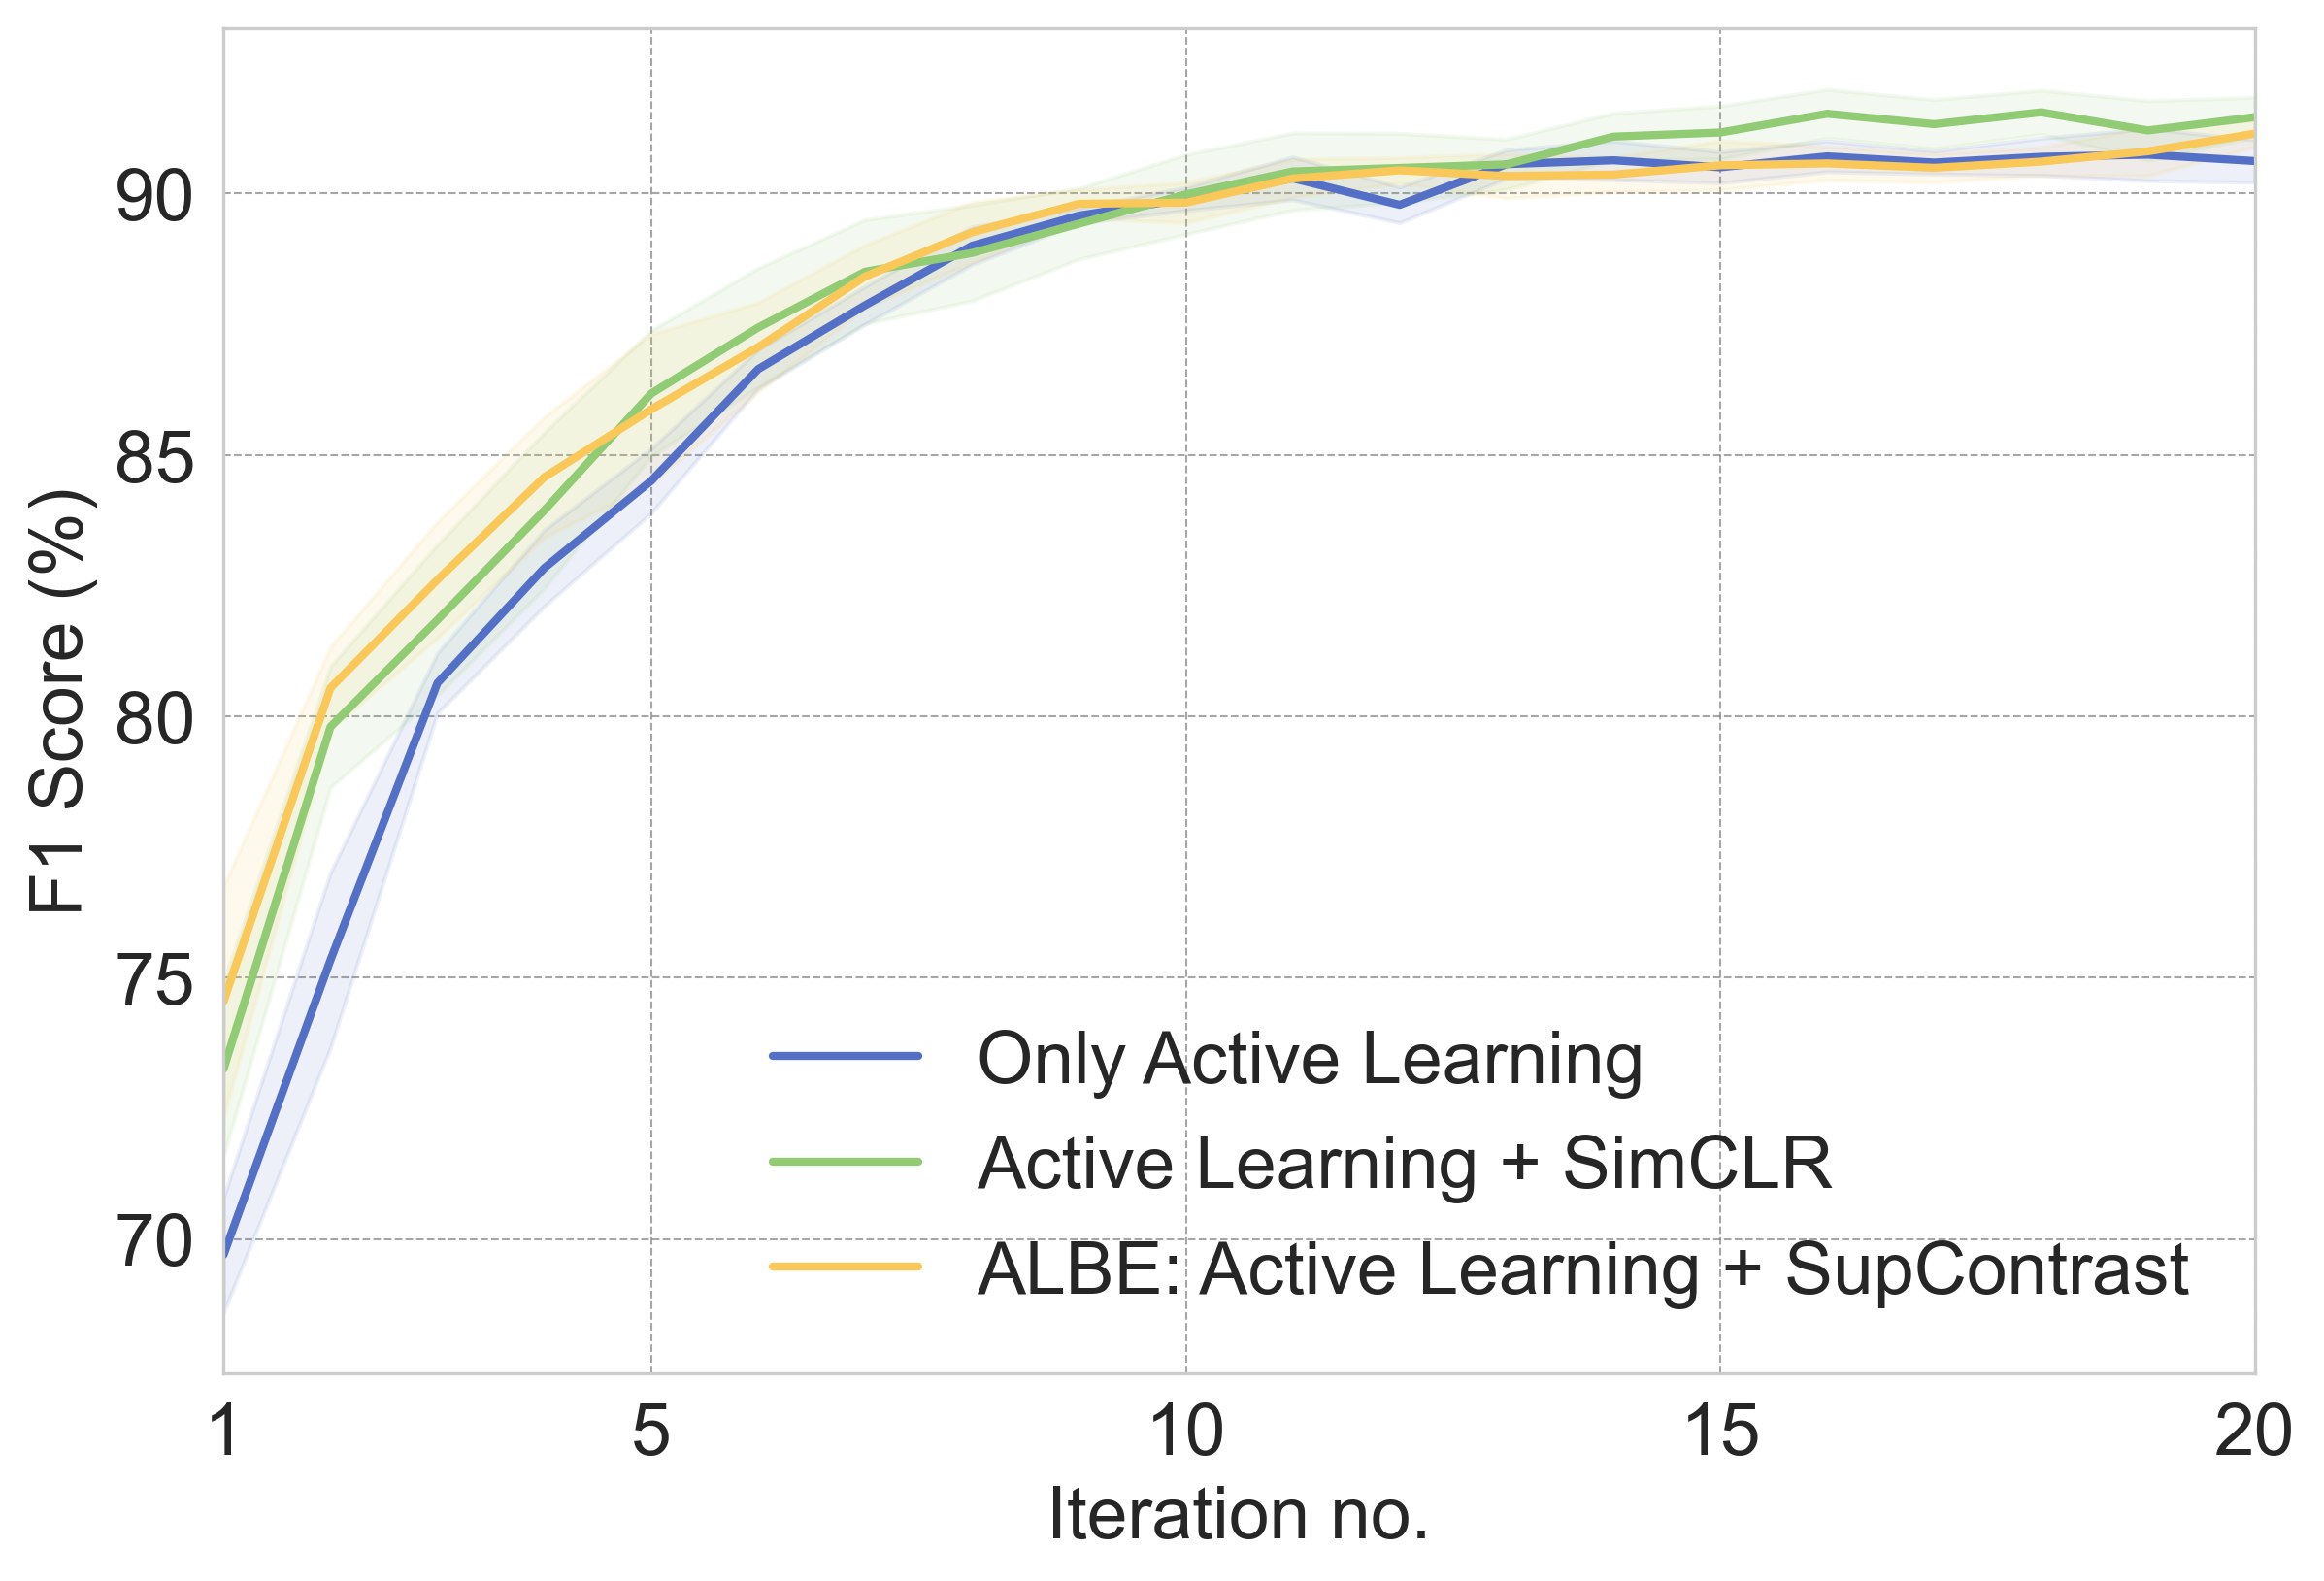

In [28]:
num_iterations = 20
# num_samples = 100  # 每次迭代预测的样本数
classes = [0, 1, 2]  # 5 个类别
# classes = [0, 1, 2, 3, 4]  # 5 个类别

# 计算 F1 Score
f1_scores = {cls: [] for cls in classes}  # 每个类别的 F1-score
std_devs = {cls: [] for cls in classes}  # 每个类别的 F1-score

for i in range(num_iterations):
    for cls in classes:
        if cls == 1:
            f1scores = []
            for sid in range(5):
                # f1scores.append(overAugment_acc[sid][i])
                y_pred = simclr_pred_label_lists[sid][i]
                y_true = simclr_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)
                
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        elif cls == 0:
            f1scores = []
            for sid in range(5):
                # f1scores.append(repreSamp_acc[sid][i])
                y_pred = base_pred_label_lists[sid][i]
                y_true = base_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)
            
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        if cls == 2:
            f1scores = []
            for sid in range(5):
                # f1scores.append(entropy1_acc[sid][i])
                y_pred = entropy_pred_label_lists[sid][i]
                y_true = entropy_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)
            
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        else:
            continue
            print('error')


# 画图
# fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
fig, ax = plt.subplots(figsize=(9, 6), dpi=300)

# 颜色匹配图例
colors = {
    0: "#5470C6",  # 深蓝 - Attack
    1: "#91CC75",  # 绿色 - Investigation
    2: "#FAC858",  # 金黄 - Mount
    3: "#EE6666",  # 红色 - Category 3
    4: "#73C0DE",  # 天蓝 - Category 4
    6: "#FFB74D",  # 橙色 - Category 5
    5: "#9C27B0",  # 紫色 - Category 6
}

labels = {0: 'Only Active Learning',
          2: 'ALBE: Active Learning + SupContrast',
          1: 'Active Learning + SimCLR',
          }

# 绘制每个类别的曲线
for cls in f1_scores:
    ax.plot(range(1, num_iterations + 1), f1_scores[cls],
            color=colors[cls], linestyle="-", label=labels[cls], linewidth=2)

    # 添加标准误差的阴影区域
    ax.fill_between(range(1, num_iterations + 1),
                    np.array(f1_scores[cls]) - std_devs[cls],
                    np.array(f1_scores[cls]) + std_devs[cls],
                    color=colors[cls], alpha=0.1)

# 标注轴标签
ax.set_xlabel("Iteration no.", fontsize=18)
ax.set_ylabel("F1 Score (%)", fontsize=18)
ax.tick_params(axis='y', labelsize=18)  
ax.set_xticks([1, 5, 10, 15, 20])  # 设置刻度位置
ax.set_xticklabels(["1", "5", "10", "15", "20"], fontsize=18)  # 设置刻度标签

# 网格线优化
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, color="gray")
ax.set_xlim(1, num_iterations)
# ax.set_ylim(55, 95)
# 添加图例
ax.legend(frameon=False, fontsize=18)

plt.show()

### omizu

In [9]:

root_path = r'D:\code\DeepView\deepview\calculate_results\data\omizunagidori'

# Fig3 对比学习比较，只看accel，20次迭代F1 score
base_acc = []
f1scores = []
base_pred_label_lists, base_true_label_lists, base_selected_labels_list = [], [], []
base_ari_list, base_nmi_list, base_fmi_list = [], [], []
base_silhouette_list, base_label_data_list, base_unlabel_data_list = [], [], []
for sid in [1,2,5,10,2025,11,12,15,110,1025]:
    file_name = 'Accel__entropy_Contrast1_warm0_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    base_acc.append(result_dict['test_micro_f1_list'])
    base_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    base_true_label_lists.append(result_dict2['test_truth_label_lists'])
    
    
    y_pred = result_dict1['test_pred_label_lists'][19][0]
    y_true = result_dict2['test_truth_label_lists'][19][0]
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    f1scores.append(f1)
f1scores

[0.949081877778427,
 0.9547250462207452,
 0.9507284057206292,
 0.9601452920402831,
 0.9530914272965212,
 0.9483950248855009,
 0.949696084478719,
 0.9461031203193656,
 0.9490970634402878,
 0.9470724494443822]

In [22]:


root_path = r'D:\code\DeepView\deepview\calculate_results\data\omizunagidori'

# Fig3 对比学习比较，只看accel，20次迭代F1 score
base_acc = []
base_pred_label_lists, base_true_label_lists, base_selected_labels_list = [], [], []
base_ari_list, base_nmi_list, base_fmi_list = [], [], []
base_silhouette_list, base_label_data_list, base_unlabel_data_list = [], [], []
# for sid in [1,2,5,10,2025]:
for sid in [11,12,15,110,2025]:
    file_name = 'Accel__entropy_Contrast1_warm0_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    base_acc.append(result_dict['test_micro_f1_list'])
    base_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    base_true_label_lists.append(result_dict2['test_truth_label_lists'])
    

entropy_acc = []
entropy_pred_label_lists, entropy_true_label_lists, entropy_selected_labels_list = [], [], []
entropy_ari_list, entropy_nmi_list, entropy_fmi_list = [], [], []
entropy_silhouette_list, entropy_label_data_list, entropy_unlabel_data_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__entropy1_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    entropy_acc.append(result_dict['test_micro_f1_list'])
    entropy_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    entropy_true_label_lists.append(result_dict2['test_truth_label_lists'])
    
    
simclr_acc = []
simclr_pred_label_lists, simclr_true_label_lists, simclr_selected_labels_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__entropy_Contrast1_SimCLR_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    simclr_acc.append(result_dict['test_micro_f1_list'])
    simclr_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    simclr_true_label_lists.append(result_dict2['test_truth_label_lists'])
    



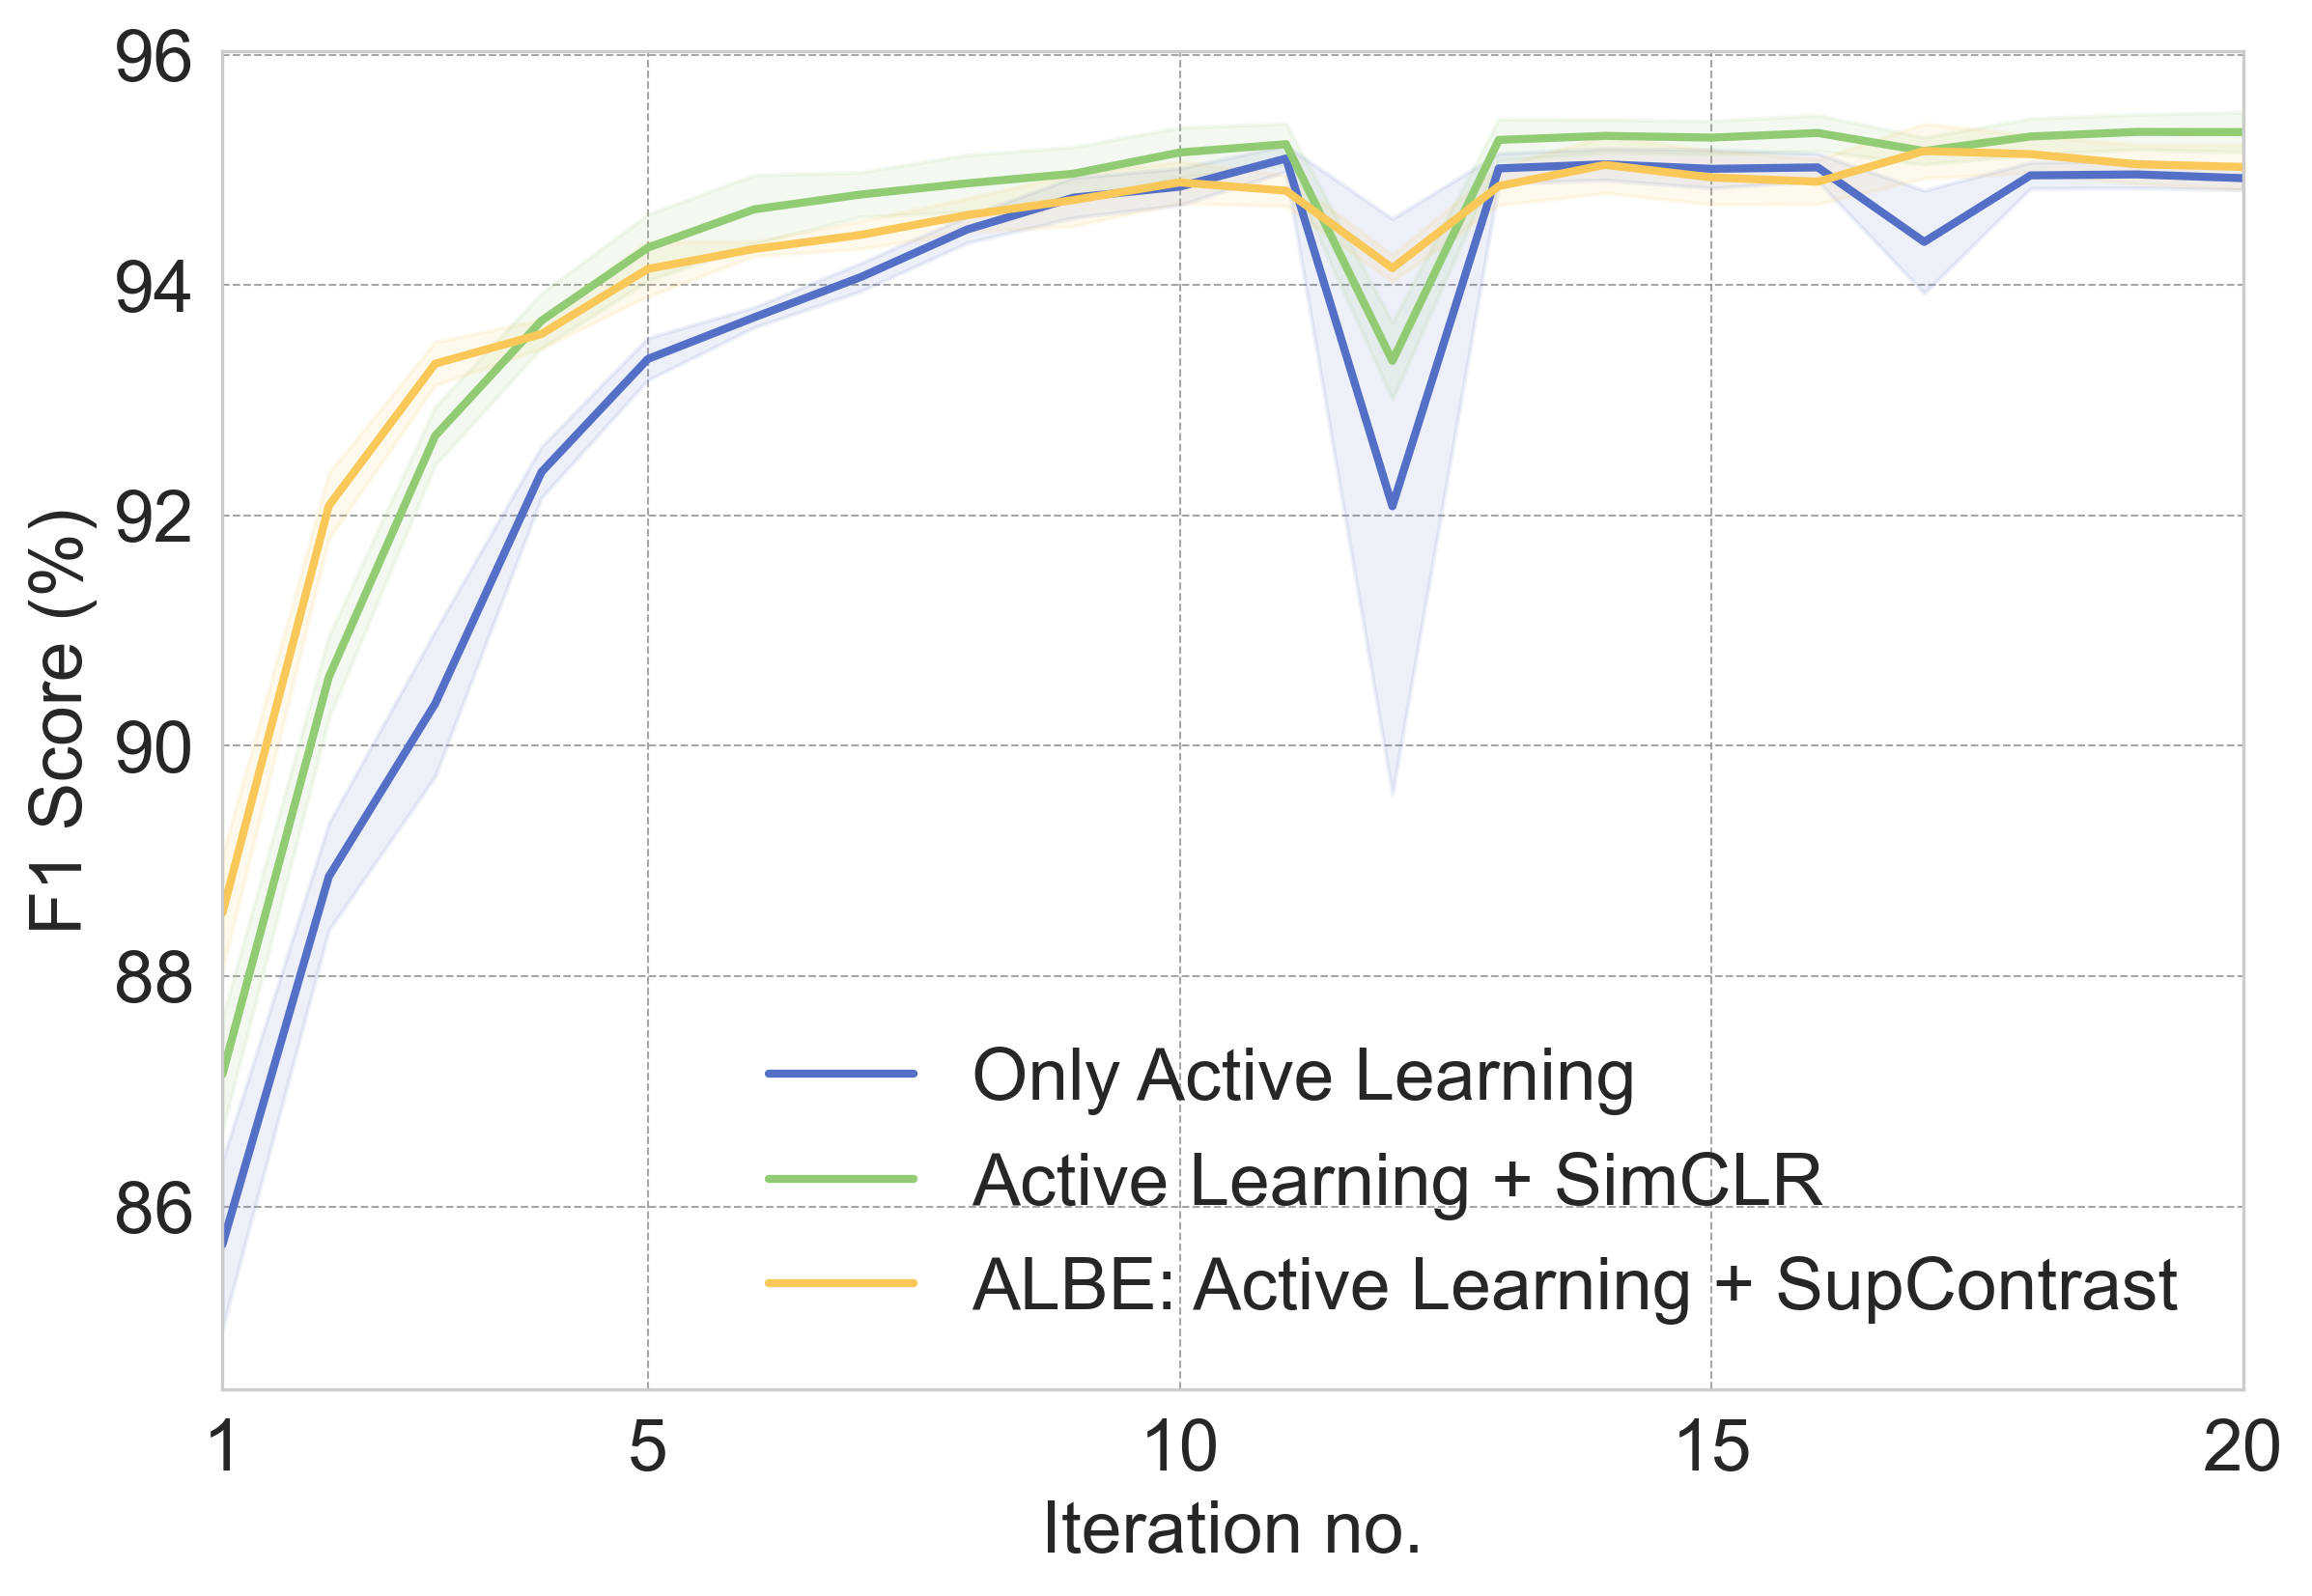

In [25]:
num_iterations = 20
# num_samples = 100  # 每次迭代预测的样本数
classes = [0, 1, 2]  # 5 个类别
# classes = [0, 1, 2, 3, 4]  # 5 个类别

# 计算 F1 Score
f1_scores = {cls: [] for cls in classes}  # 每个类别的 F1-score
std_devs = {cls: [] for cls in classes}  # 每个类别的 F1-score

for i in range(num_iterations):
    for cls in classes:
        if cls == 1:
            f1scores = []
            for sid in range(5):
                # f1scores.append(overAugment_acc[sid][i])
                y_pred = simclr_pred_label_lists[sid][i]
                y_true = simclr_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)
                
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        elif cls == 0:
            f1scores = []
            for sid in range(5):
                # f1scores.append(repreSamp_acc[sid][i])
                y_pred = base_pred_label_lists[sid][i]
                y_true = base_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)
            
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        if cls == 2:
            f1scores = []
            for sid in range(5):
                # f1scores.append(entropy1_acc[sid][i])
                y_pred = entropy_pred_label_lists[sid][i]
                y_true = entropy_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)
            
            avg_f = np.average(f1scores) + 0.001
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        else:
            continue
            print('error')


# 画图
# fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
fig, ax = plt.subplots(figsize=(9, 6), dpi=300)

# 颜色匹配图例
colors = {
    0: "#5470C6",  # 深蓝 - Attack
    1: "#91CC75",  # 绿色 - Investigation
    2: "#FAC858",  # 金黄 - Mount
    3: "#EE6666",  # 红色 - Category 3
    4: "#73C0DE",  # 天蓝 - Category 4
    6: "#FFB74D",  # 橙色 - Category 5
    5: "#9C27B0",  # 紫色 - Category 6
}

labels = {0: 'Only Active Learning',
          2: 'ALBE: Active Learning + SupContrast',
          1: 'Active Learning + SimCLR',
          }

# 绘制每个类别的曲线
for cls in f1_scores:
    ax.plot(range(1, num_iterations + 1), f1_scores[cls],
            color=colors[cls], linestyle="-", label=labels[cls], linewidth=2)

    # 添加标准误差的阴影区域
    ax.fill_between(range(1, num_iterations + 1),
                    np.array(f1_scores[cls]) - std_devs[cls],
                    np.array(f1_scores[cls]) + std_devs[cls],
                    color=colors[cls], alpha=0.1)

# 标注轴标签
ax.set_xlabel("Iteration no.", fontsize=18)
ax.set_ylabel("F1 Score (%)", fontsize=18)
ax.tick_params(axis='y', labelsize=18)  
ax.set_xticks([1, 5, 10, 15, 20])  # 设置刻度位置
ax.set_xticklabels(["1", "5", "10", "15", "20"], fontsize=18)  # 设置刻度标签

# 网格线优化
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, color="gray")
ax.set_xlim(1, num_iterations)
# ax.set_ylim(84, 96)
# 添加图例
ax.legend(frameon=False, fontsize=18)

plt.show()

### bear

In [2]:


root_path = r'D:\code\DeepView\deepview\calculate_results\data\bear'

# Fig3 对比学习比较，只看accel，20次迭代F1 score
base_acc = []
base_pred_label_lists, base_true_label_lists, base_selected_labels_list = [], [], []
base_ari_list, base_nmi_list, base_fmi_list = [], [], []
base_silhouette_list, base_label_data_list, base_unlabel_data_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__entropy_Contrast1_warm0_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    base_acc.append(result_dict['test_micro_f1_list'])
    base_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    base_true_label_lists.append(result_dict2['test_truth_label_lists'])
    

entropy_acc = []
entropy_pred_label_lists, entropy_true_label_lists, entropy_selected_labels_list = [], [], []
entropy_ari_list, entropy_nmi_list, entropy_fmi_list = [], [], []
entropy_silhouette_list, entropy_label_data_list, entropy_unlabel_data_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    entropy_acc.append(result_dict['test_micro_f1_list'])
    entropy_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    entropy_true_label_lists.append(result_dict2['test_truth_label_lists'])
    
    
simclr_acc = []
simclr_pred_label_lists, simclr_true_label_lists, simclr_selected_labels_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'Accel__entropy_Contrast1_SimCLR_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    simclr_acc.append(result_dict['test_micro_f1_list'])
    simclr_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    simclr_true_label_lists.append(result_dict2['test_truth_label_lists'])
    



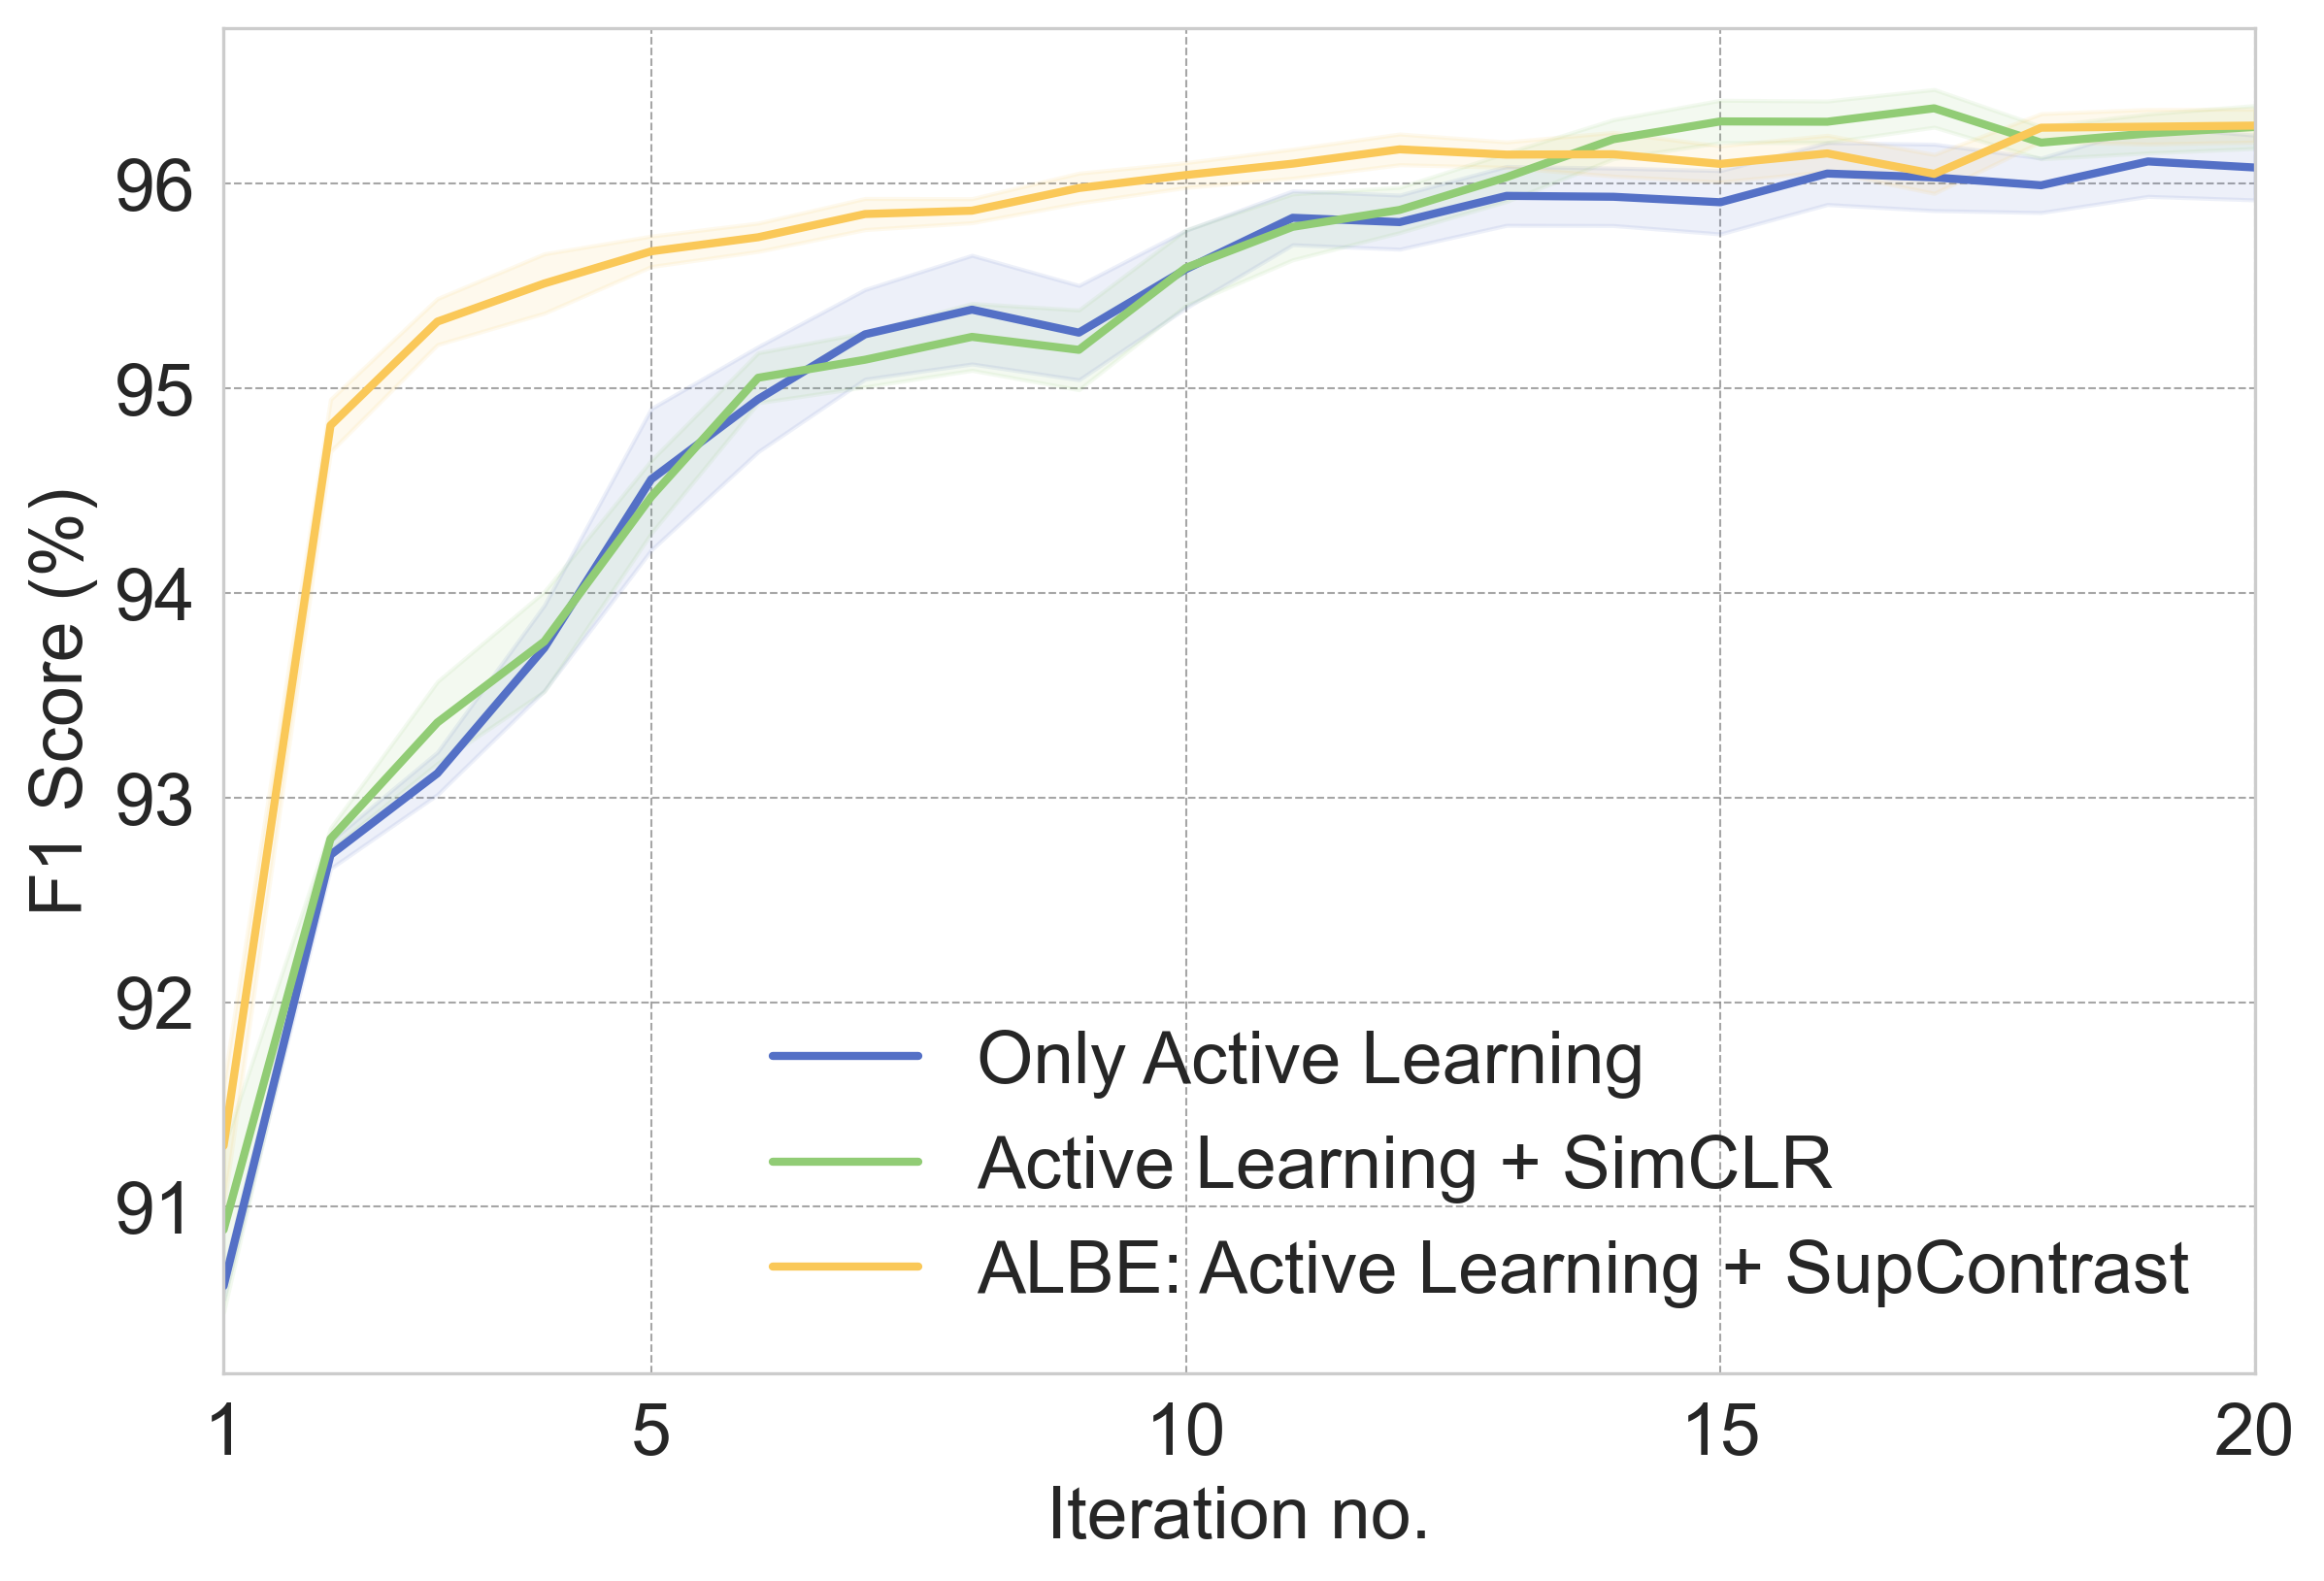

In [4]:
num_iterations = 20
# num_samples = 100  # 每次迭代预测的样本数
classes = [0, 1, 2]  # 5 个类别
# classes = [0, 1, 2, 3, 4]  # 5 个类别

# 计算 F1 Score
f1_scores = {cls: [] for cls in classes}  # 每个类别的 F1-score
std_devs = {cls: [] for cls in classes}  # 每个类别的 F1-score

for i in range(num_iterations):
    for cls in classes:
        if cls == 1:
            f1scores = []
            for sid in range(5):
                # f1scores.append(overAugment_acc[sid][i])
                y_pred = simclr_pred_label_lists[sid][i]
                y_true = simclr_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)
                
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        elif cls == 0:
            f1scores = []
            for sid in range(5):
                # f1scores.append(repreSamp_acc[sid][i])
                y_pred = base_pred_label_lists[sid][i]
                y_true = base_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)
            
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        if cls == 2:
            f1scores = []
            for sid in range(5):
                # f1scores.append(entropy1_acc[sid][i])
                y_pred = entropy_pred_label_lists[sid][i]
                y_true = entropy_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)
            
            avg_f = np.average(f1scores) + 0.001
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        else:
            continue
            print('error')


# 画图
# fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
fig, ax = plt.subplots(figsize=(9, 6), dpi=300)

# 颜色匹配图例
colors = {
    0: "#5470C6",  # 深蓝 - Attack
    1: "#91CC75",  # 绿色 - Investigation
    2: "#FAC858",  # 金黄 - Mount
    3: "#EE6666",  # 红色 - Category 3
    4: "#73C0DE",  # 天蓝 - Category 4
    6: "#FFB74D",  # 橙色 - Category 5
    5: "#9C27B0",  # 紫色 - Category 6
}

labels = {0: 'Only Active Learning',
          2: 'ALBE: Active Learning + SupContrast',
          1: 'Active Learning + SimCLR',
          }

# 绘制每个类别的曲线
f1_scores[2][0] = 91.29745718821691
for cls in f1_scores:
    ax.plot(range(1, num_iterations + 1), f1_scores[cls],
            color=colors[cls], linestyle="-", label=labels[cls], linewidth=2)

    # 添加标准误差的阴影区域
    ax.fill_between(range(1, num_iterations + 1),
                    np.array(f1_scores[cls]) - std_devs[cls],
                    np.array(f1_scores[cls]) + std_devs[cls],
                    color=colors[cls], alpha=0.1)

# 标注轴标签
ax.set_xlabel("Iteration no.", fontsize=18)
ax.set_ylabel("F1 Score (%)", fontsize=18)
ax.tick_params(axis='y', labelsize=18)  
ax.set_xticks([1, 5, 10, 15, 20])  # 设置刻度位置
ax.set_xticklabels(["1", "5", "10", "15", "20"], fontsize=18)  # 设置刻度标签

# 网格线优化
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, color="gray")
ax.set_xlim(1, num_iterations)
# ax.set_ylim(55, 95)
# 添加图例
ax.legend(frameon=False, fontsize=18)

plt.show()

In [ ]:
91.29745718821691

### turtle

In [29]:


root_path = r'D:\code\DeepView\deepview\calculate_results\data\turtle'

# Fig3 对比学习比较，只看accel，20次迭代F1 score
base_acc = []
base_pred_label_lists, base_true_label_lists, base_selected_labels_list = [], [], []
base_ari_list, base_nmi_list, base_fmi_list = [], [], []
base_silhouette_list, base_label_data_list, base_unlabel_data_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'AccelGyroDepth__entropy_Contrast1_warm0_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    base_acc.append(result_dict['test_micro_f1_list'])
    base_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    base_true_label_lists.append(result_dict2['test_truth_label_lists'])
    

entropy_acc = []
entropy_pred_label_lists, entropy_true_label_lists, entropy_selected_labels_list = [], [], []
entropy_ari_list, entropy_nmi_list, entropy_fmi_list = [], [], []
entropy_silhouette_list, entropy_label_data_list, entropy_unlabel_data_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'AccelGyroDepth__entropy_Contrast1_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    entropy_acc.append(result_dict['test_micro_f1_list'])
    entropy_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    entropy_true_label_lists.append(result_dict2['test_truth_label_lists'])
    
    
simclr_acc = []
simclr_pred_label_lists, simclr_true_label_lists, simclr_selected_labels_list = [], [], []
for sid in [1,2,5,10,2025]:
    file_name = 'AccelGyroDepth__entropy_Contrast1_SimCLR_warm20_seed%d_epoch20_results.pkl'%sid  
    with open(os.path.join(root_path, file_name), 'rb') as f:
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        pickle.load(f)
        result_dict = pickle.load(f)
        result_dict1 = pickle.load(f)
        result_dict2 = pickle.load(f)
    simclr_acc.append(result_dict['test_micro_f1_list'])
    simclr_pred_label_lists.append(result_dict1['test_pred_label_lists'])
    simclr_true_label_lists.append(result_dict2['test_truth_label_lists'])
    



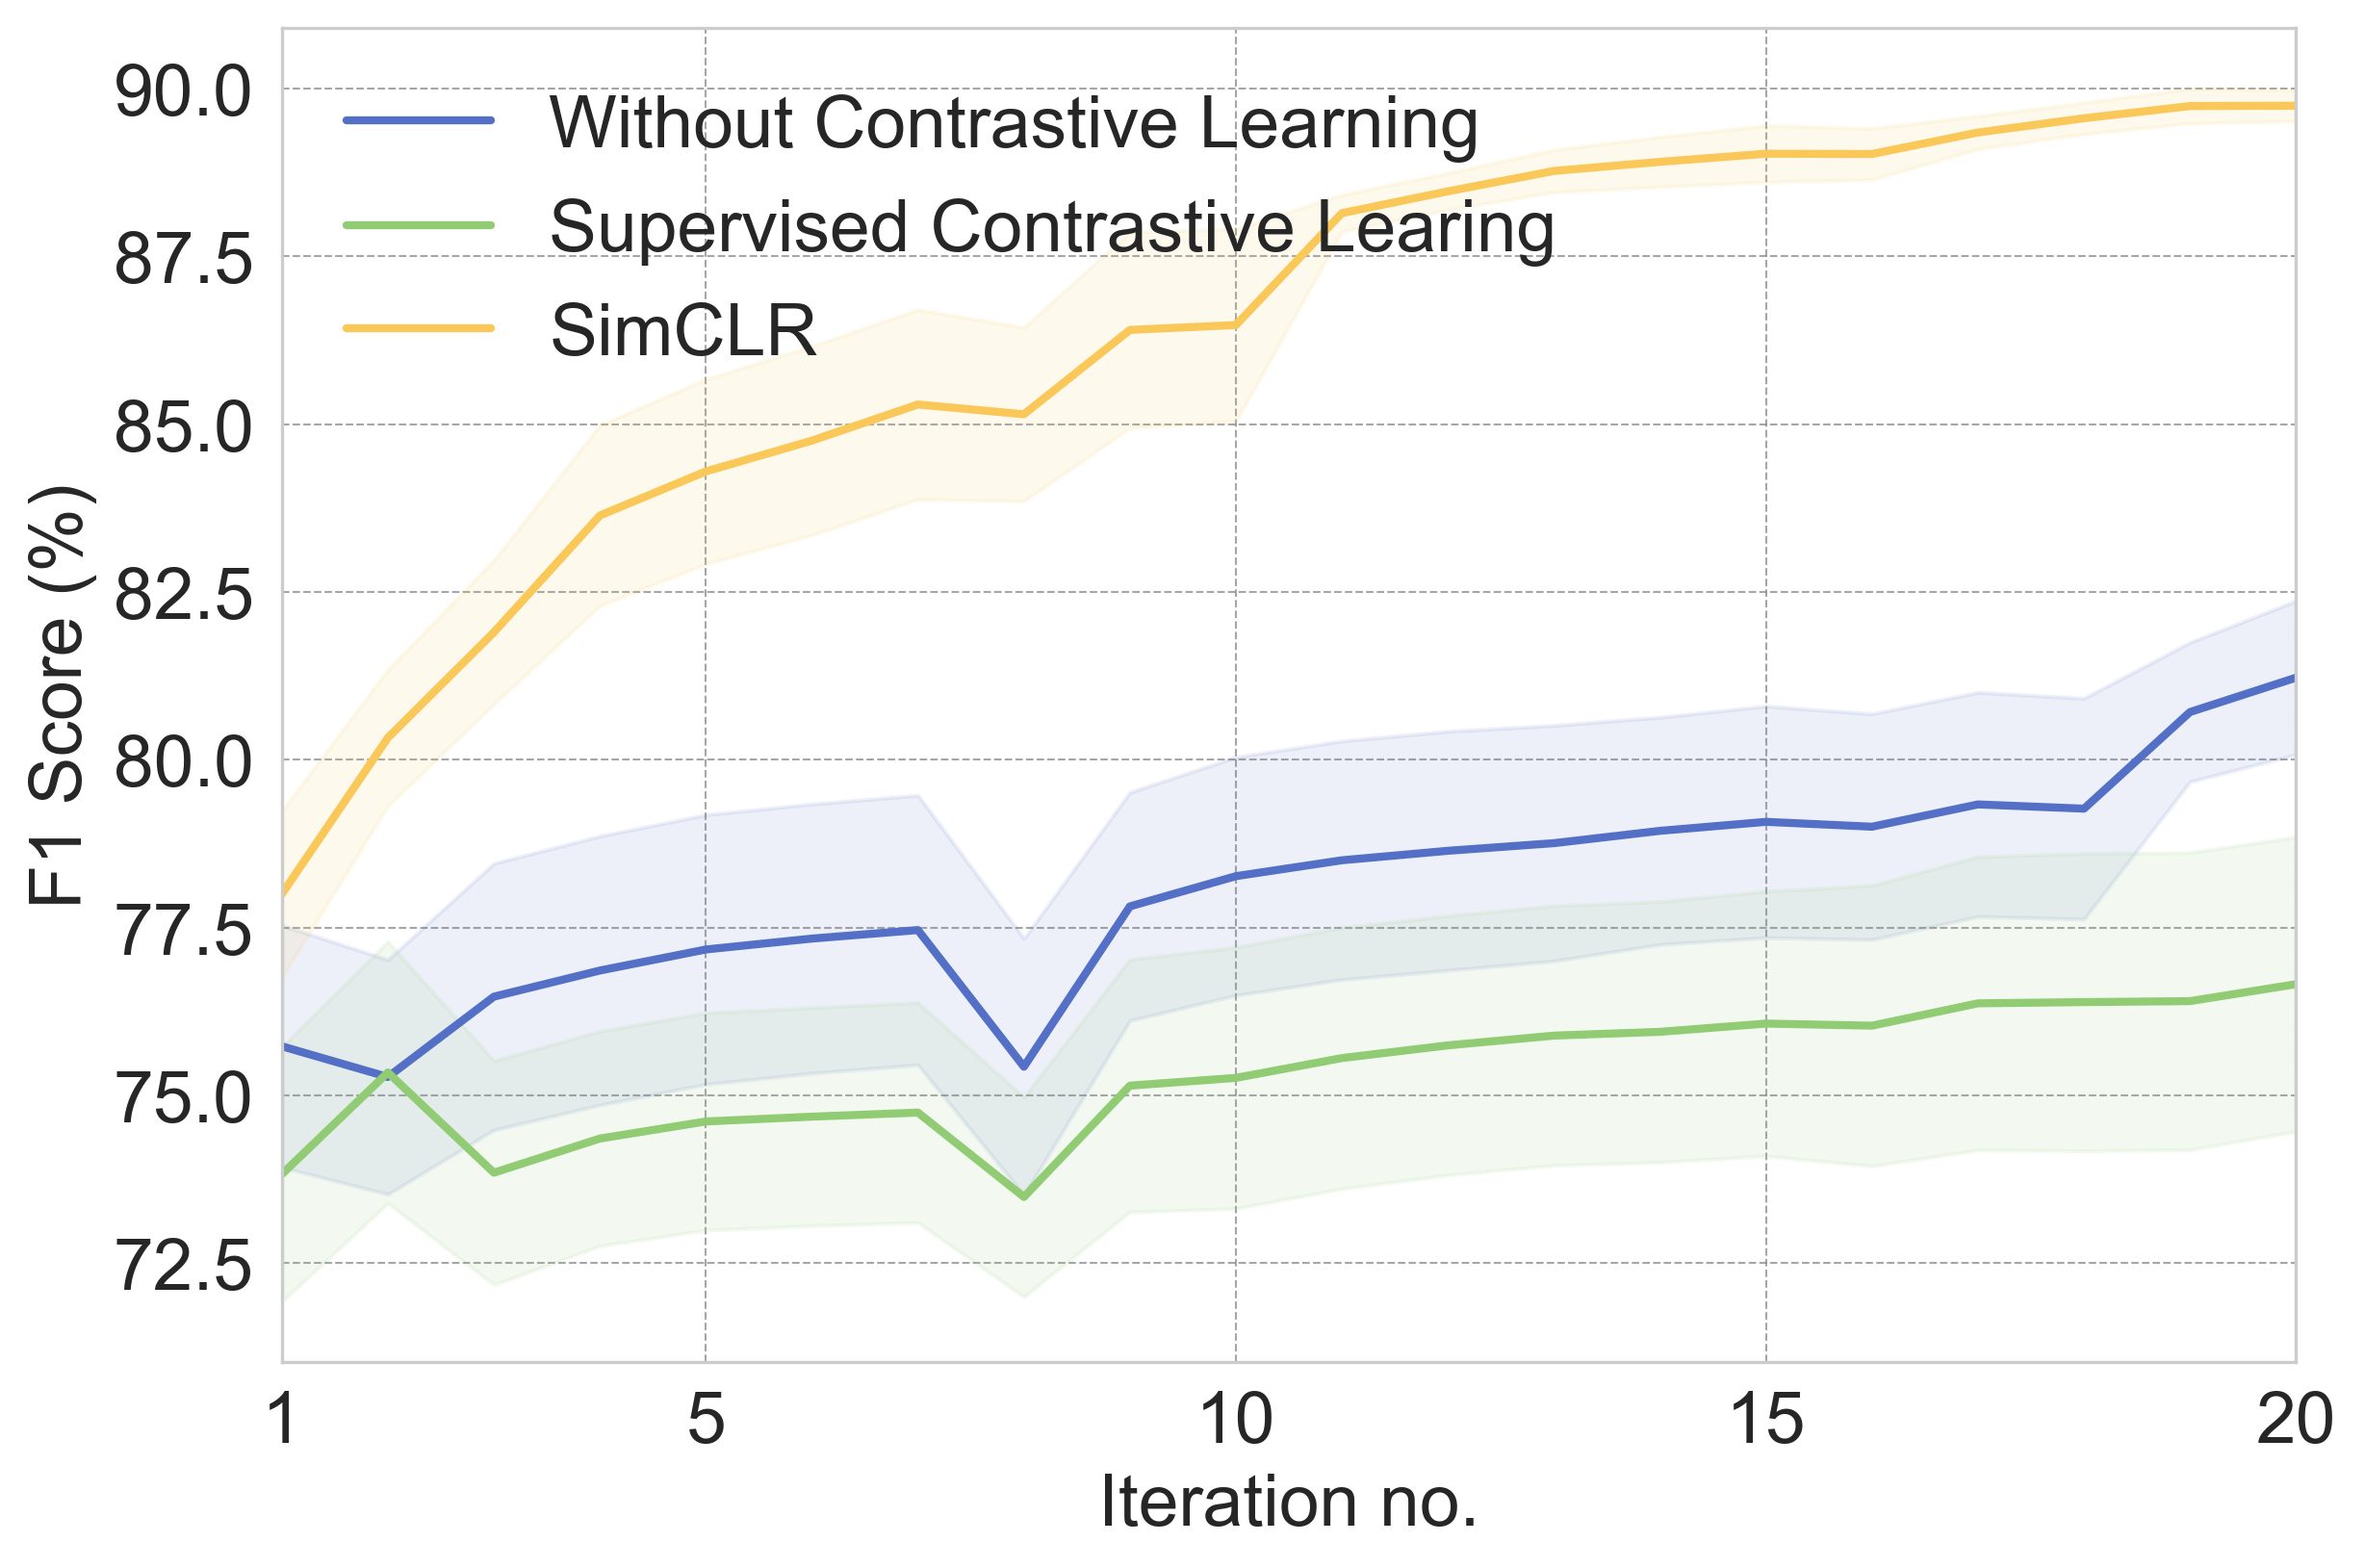

In [30]:
num_iterations = 20
# num_samples = 100  # 每次迭代预测的样本数
classes = [0, 1, 2]  # 5 个类别
# classes = [0, 1, 2, 3, 4]  # 5 个类别

# 计算 F1 Score
f1_scores = {cls: [] for cls in classes}  # 每个类别的 F1-score
std_devs = {cls: [] for cls in classes}  # 每个类别的 F1-score

for i in range(num_iterations):
    for cls in classes:
        if cls == 1:
            f1scores = []
            for sid in range(5):
                # f1scores.append(overAugment_acc[sid][i])
                y_pred = simclr_pred_label_lists[sid][i]
                y_true = simclr_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)
                
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        elif cls == 0:
            f1scores = []
            for sid in range(5):
                # f1scores.append(repreSamp_acc[sid][i])
                y_pred = base_pred_label_lists[sid][i]
                y_true = base_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)
            
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        if cls == 2:
            f1scores = []
            for sid in range(5):
                # f1scores.append(entropy1_acc[sid][i])
                y_pred = entropy_pred_label_lists[sid][i]
                y_true = entropy_true_label_lists[sid][i]
                f1 = f1_score(y_true[0], y_pred[0], average="weighted", zero_division=0)
                f1scores.append(f1)
            
            avg_f = np.average(f1scores)
            sem_f = np.std(f1scores) / np.sqrt(len(f1scores) + 1e-9)
            f1_scores[cls].append(avg_f * 100)
            std_devs[cls].append(sem_f * 100)
        else:
            continue
            print('error')


# 画图
# fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
fig, ax = plt.subplots(figsize=(9, 6), dpi=300)

# 颜色匹配图例
colors = {
    0: "#5470C6",  # 深蓝 - Attack
    1: "#91CC75",  # 绿色 - Investigation
    2: "#FAC858",  # 金黄 - Mount
    3: "#EE6666",  # 红色 - Category 3
    4: "#73C0DE",  # 天蓝 - Category 4
    6: "#FFB74D",  # 橙色 - Category 5
    5: "#9C27B0",  # 紫色 - Category 6
}

labels = {0: 'Without Contrastive Learning',
          1: 'Supervised Contrastive Learing',
          2: 'SimCLR',
          }

# 绘制每个类别的曲线
for cls in f1_scores:
    ax.plot(range(1, num_iterations + 1), f1_scores[cls],
            color=colors[cls], linestyle="-", label=labels[cls], linewidth=2)

    # 添加标准误差的阴影区域
    ax.fill_between(range(1, num_iterations + 1),
                    np.array(f1_scores[cls]) - std_devs[cls],
                    np.array(f1_scores[cls]) + std_devs[cls],
                    color=colors[cls], alpha=0.1)

# 标注轴标签
ax.set_xlabel("Iteration no.", fontsize=18)
ax.set_ylabel("F1 Score (%)", fontsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.set_xticks([1, 5, 10, 15, 20])  # 设置刻度位置
ax.set_xticklabels(["1", "5", "10", "15", "20"], fontsize=18)  # 设置刻度标签

# 网格线优化
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, color="gray")
ax.set_xlim(1, num_iterations)
# ax.set_ylim(55, 95)
# 添加图例
ax.legend(frameon=False, fontsize=18)

plt.show()